This notebook explores what features of a question correlate with the difficulty rating that ChatGPT assigns to it.

## Load the data
Reads the CSV. Each row is one generated question, described by ~48 columns of code and text-complexity metrics.

In [1]:
!wget https://raw.githubusercontent.com/lopezbec/Python_LLM_dificulty/refs/heads/main/code_counts.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("code_counts.csv")

# First sanity check
print("Shape:", df.shape)
print("\nFirst few rows:")
df.head()

--2026-06-07 20:39:14--  https://raw.githubusercontent.com/lopezbec/Python_LLM_dificulty/refs/heads/main/code_counts.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 69381314 (66M) [text/plain]
Saving to: ‘code_counts.csv’

code_counts.csv     100%[===================>]  66.17M  81.7MB/s    in 0.8s    

2026-06-07 20:39:18 (81.7 MB/s) - ‘code_counts.csv’ saved [69381314/69381314]

Shape: (4002, 51)

First few rows:


,hpc_folder,hpc_filename,parent_folder,parent_filename,HPC_extraction_type,set_number,method,subject,model,question_number,...,in_question_chars,elsewhere_chars,note,question_embedding,answers_embedding,mc_choices_sim_matrix,mc_choices_sim_mean,mc_choices_sim_max,mc_choices_sim_pair,mc_choices_n
0,JSON_individualQs_HPC_done,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,NaN,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,LLM,10,drag-and-drop,If-Statements,gpt-4o-mini,10,...,7,78,NaN,"[0.03737969696521759, 0.058951400220394135, -0...","[0.0632529929280281, 0.10908082127571106, -0.0...","[[1.0000001192092896, 0.3368501663208008, 0.79...",0.4648,0.7903,"[0, 2]",3
1,JSON_individualQs_HPC_done,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,NaN,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,LLM,10,drag-and-drop,If-Statements,gpt-4o-mini,1,...,0,62,NaN,"[0.010622750967741013, 0.07696312665939331, 0....","[-0.020988594740629196, 0.08703333884477615, 0...","[[1.0000003576278687, 0.9657249450683594, 0.92...",0.9517,0.9728,"[0, 3]",4
2,JSON_individualQs_HPC_done,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,NaN,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,LLM,10,drag-and-drop,If-Statements,gpt-4o-mini,2,...,13,39,NaN,"[0.013367009349167347, 0.05568365752696991, 0....","[0.0013841724721714854, 0.024392785504460335, ...","[[1.0, 0.9893238544464111, 0.8499612808227539,...",0.8762,0.9893,"[0, 1]",4
3,JSON_individualQs_HPC_done,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,NaN,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,LLM,10,drag-and-drop,If-Statements,gpt-4o-mini,3,...,5,27,NaN,"[0.04825473576784134, 0.12876395881175995, -0....","[0.05114741250872612, 0.12854506075382233, -0....","[[0.9999998807907104, 0.23046284914016724], [0...",0.2305,0.2305,"[0, 1]",2
4,JSON_individualQs_HPC_done,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,NaN,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,LLM,10,drag-and-drop,If-Statements,gpt-4o-mini,4,...,28,118,NaN,"[0.025255111977458, 0.016033248975872993, -0.0...","[0.022638650611042976, 0.054916393011808395, -...","[[1.0, 0.5360086560249329, 0.6038275957107544,...",0.6877,0.9725,"[0, 3]",4


## Plot styling and a fixed model order
Sets a consistent visual style for all plots and locks in the order models appear in (smaller → larger within each family). Using a fixed order across every chart makes comparisons readable.

In [2]:
# Make plots look nicer by default
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

# Define a consistent model order for all plots
MODEL_ORDER = ["gpt-4o-mini", "gpt-4o", "o1-mini", "o1", "o3-mini"]

print("Setup complete.")

Setup complete.


## Sanity-check the experimental design
Counts rows by model, method, subject, and extraction type. We expect ~800 questions per model (5 × 800 ≈ 4,000) and balanced coverage across methods and subjects.

In [3]:
# How many of each kind?
print("=== ROWS PER MODEL ===")
print(df["model"].value_counts())

print("\n=== ROWS PER METHOD ===")
print(df["method"].value_counts())

print("\n=== ROWS PER SUBJECT ===")
print(df["subject"].value_counts())

print("\n=== EXTRACTION TYPE ===")
print(df["HPC_extraction_type"].value_counts(dropna=False))

print("\n=== DIFFICULTY RANGE (question_number) ===")
print(df["question_number"].describe())
print("\nValue counts:")
print(df["question_number"].value_counts().sort_index())

=== ROWS PER MODEL ===
model
o1-mini        801
o3-mini        801
gpt-4o-mini    800
gpt-4o         800
o1             800
Name: count, dtype: int64

=== ROWS PER METHOD ===
method
multiple-choice      1002
drag-and-drop        1000
fill-in-the-blank    1000
true-false           1000
Name: count, dtype: int64

=== ROWS PER SUBJECT ===
subject
Loops            2002
If-Statements    2000
Name: count, dtype: int64

=== EXTRACTION TYPE ===
HPC_extraction_type
LLM       3968
Manual      34
Name: count, dtype: int64

=== DIFFICULTY RANGE (question_number) ===
count    4002.000000
mean        5.502249
std         2.873770
min         1.000000
25%         3.000000
50%         6.000000
75%         8.000000
max        11.000000
Name: question_number, dtype: float64

Value counts:
question_number
1     400
2     400
3     400
4     400
5     400
6     400
7     400
8     400
9     401
10    400
11      1
Name: count, dtype: int64


## Data-quality note: excluding the question_number = 11 outlier

The CSV contains exactly one row with `question_number = 11`, which falls outside the requested 1-to-9 ranking the models were instructed to produce. We identify and exclude this row before any analysis. The cell below prints its source so the exclusion is documented in the notebook itself.

The excluded row was generated by **o1-mini** using the **multiple-choice** question method on the topic of **Loops** (file: `set_3_multiple-choice_Loops_o1-mini_cleaned_q11.json`). This appears to be a one-off where the model deviated from the requested ranking when generating that question set.

In [4]:
# Locate the single question_number = 11 outlier
outlier = df[df["question_number"] == 11]
print(f"Number of rows with question_number = 11: {len(outlier)}")
print(f"\nSource details:")
print(outlier[["model", "method", "subject", "parent_filename"]].to_string(index=False))

# Exclude the outlier from all downstream analysis
before = len(df)
df = df[df["question_number"] != 11].reset_index(drop=True)
print(f"\nRows before exclusion: {before}")
print(f"Rows after exclusion:  {len(df)}")

Number of rows with question_number = 11: 1

Source details:
  model          method subject                                      parent_filename
o1-mini multiple-choice   Loops set_3_multiple-choice_Loops_o1-mini_cleaned_q11.json

Rows before exclusion: 4002
Rows after exclusion:  4001


## Mean of every HPC complexity metric, per model
The first real comparison. Each row is a model; each column is a complexity metric measured on the HPC files (the code shown to human participants).

In [5]:
# All the HPC complexity metrics at once
hpc_metrics = [
    "hpc_snippets", "hpc_newlines", "hpc_chars", "hpc_chars_nonws",
    "hpc_pykeywords", "hpc_pykeywords_cf", "hpc_max_nesting_depth",
    "hpc_tokens", "hpc_avg_tokens_per_code_line", "hpc_operators",
    "hpc_operators_per_token_ratio", "hpc_avg_line_length", "hpc_max_line_length"
]

# Mean of each metric per model
summary = df.groupby("model")[hpc_metrics].mean().round(2)
summary = summary.reindex(MODEL_ORDER)  # use our consistent order
summary

,hpc_snippets,hpc_newlines,hpc_chars,hpc_chars_nonws,hpc_pykeywords,hpc_pykeywords_cf,hpc_max_nesting_depth,hpc_tokens,hpc_avg_tokens_per_code_line,hpc_operators,hpc_operators_per_token_ratio,hpc_avg_line_length,hpc_max_line_length
model,,,,,,,,,,,,,
gpt-4o-mini,3.06,0.13,38.26,32.58,2.92,1.07,0.05,5.66,1.52,0.0,0.0,9.29,13.57
gpt-4o,3.57,0.26,40.60,34.26,3.12,1.10,0.12,5.79,1.35,0.0,0.0,7.97,12.23
o1-mini,3.69,0.28,49.84,41.47,3.53,1.38,0.15,7.20,1.75,0.0,0.0,10.65,15.55
o1,4.13,0.23,51.70,44.13,3.86,1.29,0.08,7.19,1.71,0.0,0.0,10.57,15.36
o3-mini,3.55,0.30,42.01,34.96,3.43,1.20,0.14,6.01,1.57,0.0,0.0,9.40,13.48


## Save the summary as a CSV
Saving intermediate results as CSVs.

In [6]:
summary.to_csv("model_summary_means.csv")
print("Saved.")

Saved.


## Boxplot: token count per model
Tokens here = identifier names (variables, functions). Here, a boxplot shows the full distribution per model: the box covers the middle 50% of values, the line is the median, whiskers show the typical range, dots are outliers. Reveals patterns that means hide.

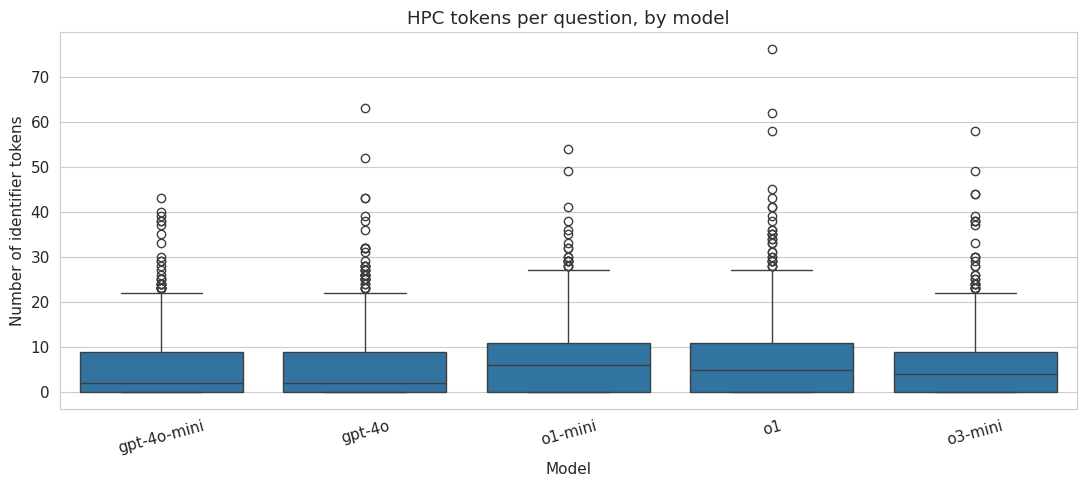

In [7]:
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x="model", y="hpc_tokens", order=MODEL_ORDER)
plt.title("HPC tokens per question, by model")
plt.ylabel("Number of identifier tokens")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("model_tokens_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

## Boxplot: control-flow keywords per model
Counts of `if`, `for`, `while`, `try`, etc.

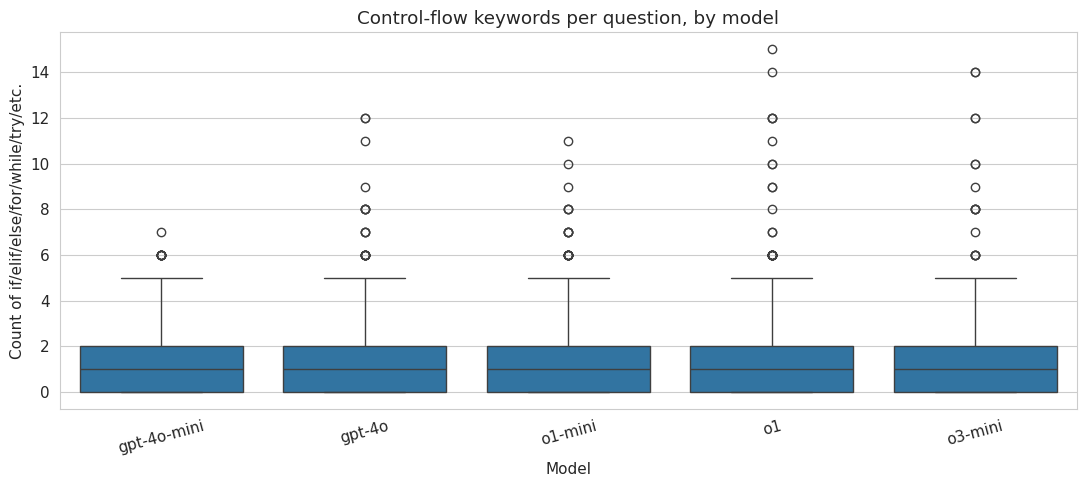

In [8]:
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x="model", y="hpc_pykeywords_cf", order=MODEL_ORDER)
plt.title("Control-flow keywords per question, by model")
plt.ylabel("Count of if/elif/else/for/while/try/etc.")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("model_controlflow_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

## Boxplot: operator density per model
Operators per token: how arithmetic-and-logic-heavy is the code per named thing. Note: this metric will turn out to be broken in our dataset (all zeros).

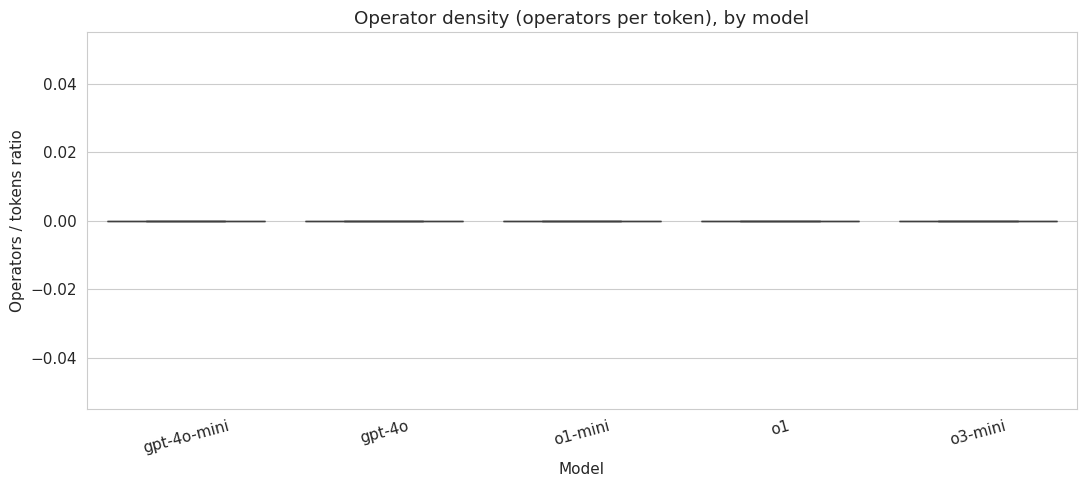

In [9]:
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x="model", y="hpc_operators_per_token_ratio", order=MODEL_ORDER)
plt.title("Operator density (operators per token), by model")
plt.ylabel("Operators / tokens ratio")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("model_operator_density_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

## Compute Spearman correlations across all features
For each feature, computes the rank correlation with difficulty (the `question_number` column, which is the ChatGPT-assigned difficulty rank) and a p-value (probability the correlation arose by chance). Features with too few non-null values are skipped. The resulting `corr_df` is the central result table of this phase.

In [10]:
from scipy.stats import spearmanr

# Every numeric feature we want to test
features = [
    # HPC (what humans saw)
    "hpc_snippets", "hpc_newlines", "hpc_chars", "hpc_chars_nonws",
    "hpc_pykeywords", "hpc_pykeywords_cf", "hpc_max_nesting_depth",
    "hpc_tokens", "hpc_avg_tokens_per_code_line", "hpc_operators",
    "hpc_operators_per_token_ratio", "hpc_avg_line_length", "hpc_max_line_length",
    # Parent (the original ChatGPT-generated question)
    "parent_chars", "parent_snippets", "parent_newlines",
    "parent_chars_from_snippets", "parent_chars_nonws",
    "parent_pykeywords", "parent_pykeywords_cf", "parent_max_nesting_depth",
    "parent_tokens", "parent_avg_tokens_per_code_line", "parent_operators",
    "parent_operators_per_token_ratio", "parent_avg_line_length",
    "parent_max_line_length",
    # Question structure
    "parent_answerchoices_count", "parent_answerchoices_avg_len",
    "in_question", "elsewhere", "in_question_chars", "elsewhere_chars",
    # Semantic similarity (only meaningful for MC; lots of NaN for others)
    "mc_choices_sim_mean", "mc_choices_sim_max", "mc_choices_n",
]

results = []
for feat in features:
    # Drop NaN pairs for this feature (some columns have missing values)
    pair = df[["question_number", feat]].dropna()
    if len(pair) < 30:  # too few observations to trust
        results.append({"feature": feat, "rho": None, "p_value": None, "n": len(pair)})
        continue
    rho, p = spearmanr(pair["question_number"], pair[feat])
    results.append({"feature": feat, "rho": round(rho, 3), "p_value": p, "n": len(pair)})

corr_df = pd.DataFrame(results)

/tmp/ipykernel_3341/510427334.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(pair["question_number"], pair[feat])
/tmp/ipykernel_3341/510427334.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(pair["question_number"], pair[feat])
/tmp/ipykernel_3341/510427334.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(pair["question_number"], pair[feat])
/tmp/ipykernel_3341/510427334.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(pair["question_number"], pair[feat])


## Save and preview the top 10 (unsorted)
Saves the correlation table as a CSV. The "top 10" preview here is just the first 10 in original order, not sorted by strength, the next cell does the proper sort.

In [11]:
corr_df.to_csv("difficulty_correlations.csv", index=False)
print("Saved difficulty_correlations.csv")
print("\nTop 10 features by correlation strength with difficulty:")
print(corr_df.head(10).to_string(index=False))

Saved difficulty_correlations.csv

Top 10 features by correlation strength with difficulty:
                     feature    rho      p_value    n
                hpc_snippets  0.104 5.196476e-11 4001
                hpc_newlines -0.015 3.572609e-01 4001
                   hpc_chars  0.177 1.625789e-29 4001
             hpc_chars_nonws  0.178 7.494870e-30 4001
              hpc_pykeywords  0.151 7.806968e-22 4001
           hpc_pykeywords_cf  0.179 3.289193e-30 4001
       hpc_max_nesting_depth -0.014 3.689188e-01 4001
                  hpc_tokens  0.196 4.696151e-36 4001
hpc_avg_tokens_per_code_line  0.164 1.168778e-25 4001
               hpc_operators    NaN          NaN 4001


## Properly rank all features by correlation strength
Sorts by absolute value of rho so the strongest correlations sit at the top, regardless of sign.

**Findings:**
- **Parent-side features dominate** the top of the ranking. The strongest correlation, `parent_chars_nonws` (ρ = 0.30), beats every HPC feature. ChatGPT's difficulty rating is more closely tied to the original question text it produced than to the extracted code shown to humans.
- **All correlations are modest**: no single feature exceeds ρ = 0.30. Difficulty is multi-causal.
- **Replicates the paper's finding**: Lopez et al. reported ρ = 0.286 for question length; we get ρ = 0.300 with a slightly cleaner length measure.

In [12]:
# Sort properly and show ALL features ranked
corr_df_sorted = corr_df.copy()
corr_df_sorted["abs_rho"] = corr_df_sorted["rho"].abs()
corr_df_sorted = corr_df_sorted.sort_values("abs_rho", ascending=False, na_position="last")

print("ALL features, ranked by correlation strength with difficulty:")
print(corr_df_sorted[["feature", "rho", "p_value", "n"]].to_string(index=False))

ALL features, ranked by correlation strength with difficulty:
                         feature    rho      p_value    n
              parent_chars_nonws  0.303 1.141843e-85 4001
      parent_chars_from_snippets  0.302 6.512225e-85 4001
                   parent_tokens  0.266 1.441458e-65 4001
          parent_max_line_length  0.252 4.361045e-59 4001
                    parent_chars  0.199 4.309573e-37 4001
                      hpc_tokens  0.196 4.696151e-36 4001
            parent_pykeywords_cf  0.195 1.726358e-35 4001
             hpc_max_line_length  0.189 1.227134e-33 4001
             hpc_avg_line_length  0.187 9.180796e-33 4001
               hpc_pykeywords_cf  0.179 3.289193e-30 4001
                 hpc_chars_nonws  0.178 7.494870e-30 4001
                       hpc_chars  0.177 1.625789e-29 4001
               in_question_chars  0.175 8.637459e-29 4001
    hpc_avg_tokens_per_code_line  0.164 1.168778e-25 4001
               parent_pykeywords  0.160 1.887294e-24 4001
          

## Diagnose the four NaN correlations
Four operator-related columns returned NaN. The diagnostic confirms they're all zero across the entire dataset. These columns should be excluded from analysis or recomputed.

In [13]:
# Why is hpc_operators NaN?
print("hpc_operators stats:")
print(df["hpc_operators"].describe())
print(f"\nUnique values: {df['hpc_operators'].nunique()}")
print(f"\nValue counts:")
print(df["hpc_operators"].value_counts().head())

hpc_operators stats:
count    4001.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: hpc_operators, dtype: float64

Unique values: 1

Value counts:
hpc_operators
0    4001
Name: count, dtype: int64


## Bar chart: all correlations at a glance
Horizontal bar chart, color-coded: parent features blue, HPC features orange, others gray. The visual proof of the "parent beats HPC" finding: the top of the chart is mostly blue.

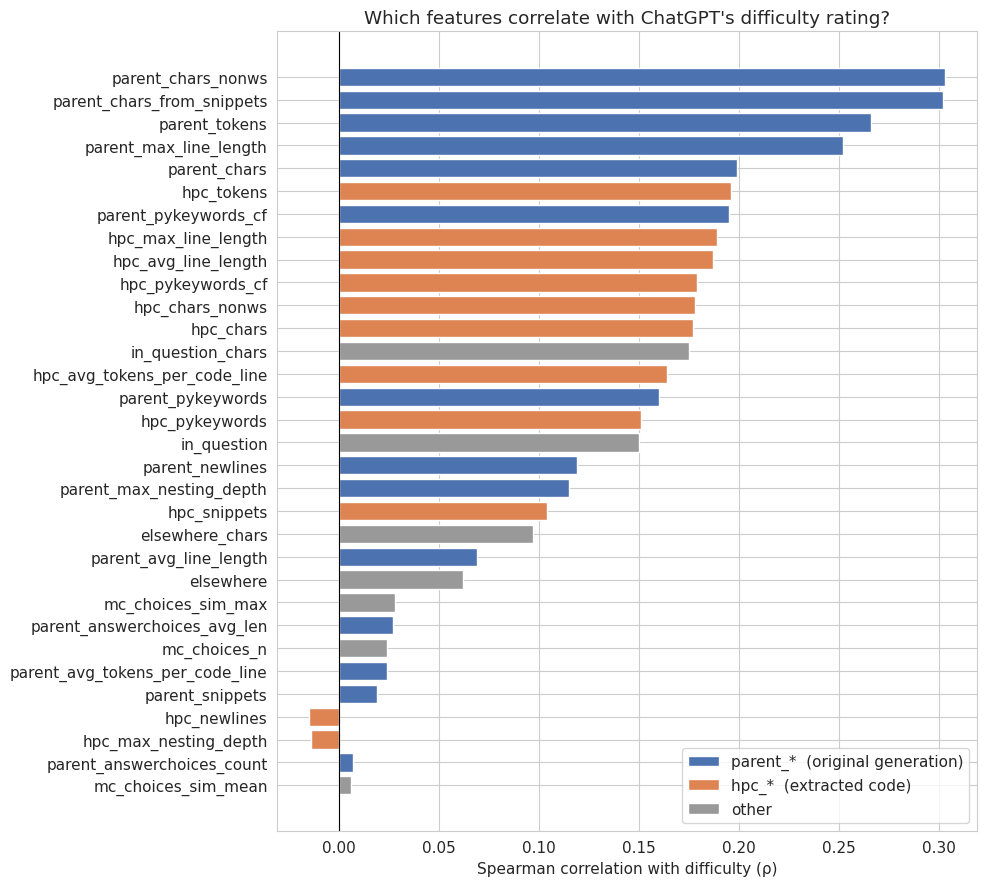

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop the dead operator columns and any rows with no rho
plot_data = corr_df_sorted.dropna(subset=["rho"]).copy()
plot_data = plot_data[~plot_data["feature"].str.contains("operator")]

# Color: parent features one color, HPC features another, others gray
def feature_color(f):
    if f.startswith("parent_"): return "#4C72B0"  # blue
    if f.startswith("hpc_"):    return "#DD8452"  # orange
    return "#999999"  # gray for the rest

colors = [feature_color(f) for f in plot_data["feature"]]

plt.figure(figsize=(10, 9))
plt.barh(plot_data["feature"], plot_data["rho"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Spearman correlation with difficulty (ρ)")
plt.title("Which features correlate with ChatGPT's difficulty rating?")
plt.gca().invert_yaxis()  # strongest at top

# Manual legend
from matplotlib.patches import Patch
legend = [Patch(facecolor="#4C72B0", label="parent_*  (original generation)"),
          Patch(facecolor="#DD8452", label="hpc_*  (extracted code)"),
          Patch(facecolor="#999999", label="other")]
plt.legend(handles=legend, loc="lower right")
plt.tight_layout()
plt.savefig("plot1_all_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

## Scatter plot: strongest feature vs difficulty
Shows `parent_chars_nonws` (the strongest predictor) against difficulty, with a regression line. The cloud of points is wide and noisy- that's what ρ = 0.30 actually looks like. The trend is real but explains only ~9% of the variance in difficulty.

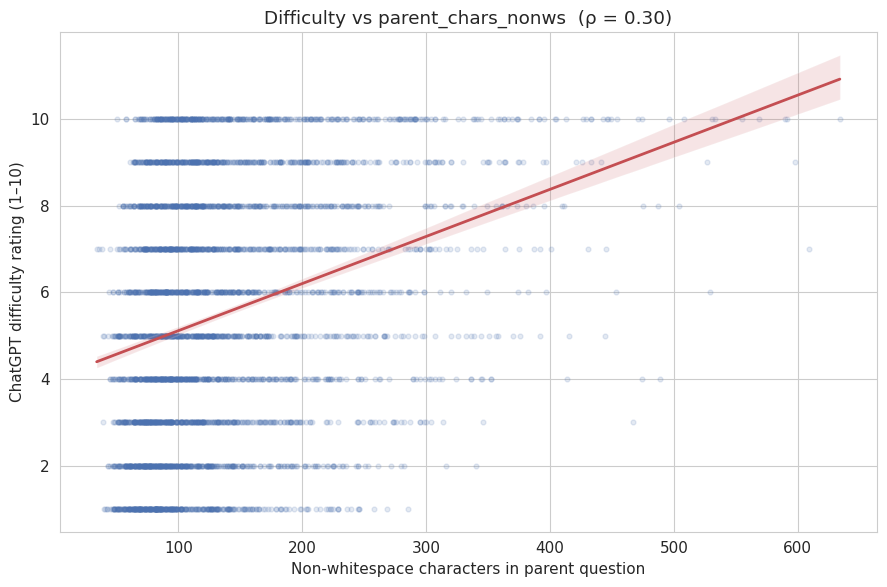

In [15]:
plt.figure(figsize=(9, 6))
sns.regplot(
    data=df,
    x="parent_chars_nonws",
    y="question_number",
    scatter_kws={"alpha": 0.15, "s": 12, "color": "#4C72B0"},
    line_kws={"color": "#C44E52", "linewidth": 2},
)
plt.title(f"Difficulty vs parent_chars_nonws  (ρ = 0.30)")
plt.xlabel("Non-whitespace characters in parent question")
plt.ylabel("ChatGPT difficulty rating (1–10)")
plt.tight_layout()
plt.savefig("plot2_scatter_top_feature.png", dpi=150, bbox_inches="tight")
plt.show()

## Boxplot version of the same relationship
Same data as the scatter cell above, but as a boxplot. Easier to read with thousands of points: medians drift upward as difficulty increases, but the boxes overlap heavily across levels.

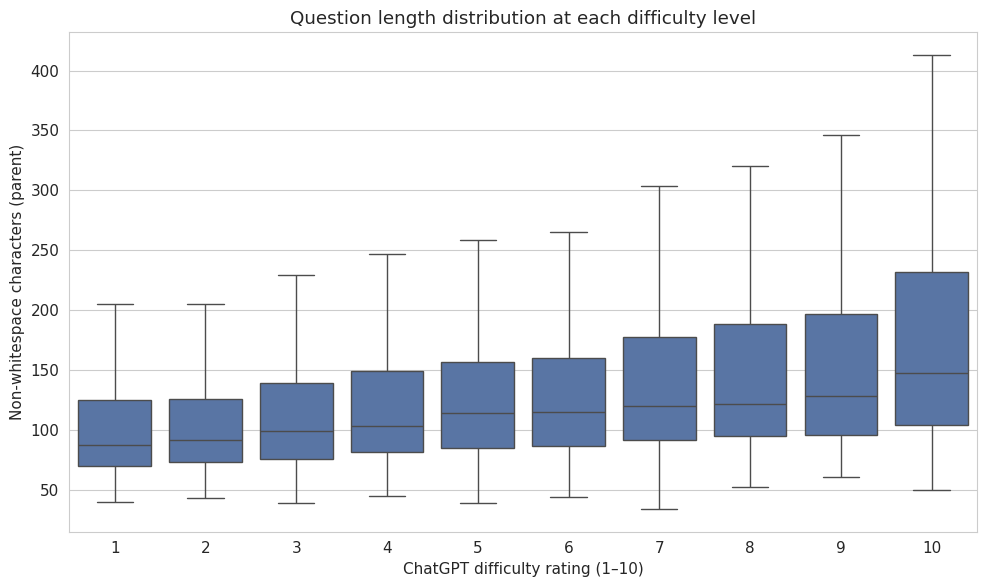

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="question_number",
    y="parent_chars_nonws",
    color="#4C72B0",
    showfliers=False,  # hide extreme outliers so boxes are readable
)
plt.title("Question length distribution at each difficulty level")
plt.xlabel("ChatGPT difficulty rating (1–10)")
plt.ylabel("Non-whitespace characters (parent)")
plt.tight_layout()
plt.savefig("plot3_boxplot_top_feature.png", dpi=150, bbox_inches="tight")
plt.show()

## Side-by-side comparison: parent vs HPC at the same metric
Visual proof of the parent-beats-HPC finding. Left panel (parent) shows a clearer upward trend than the right panel (HPC). When ChatGPT rates a question difficult, the original text length predicts it better than the extracted-code length does.

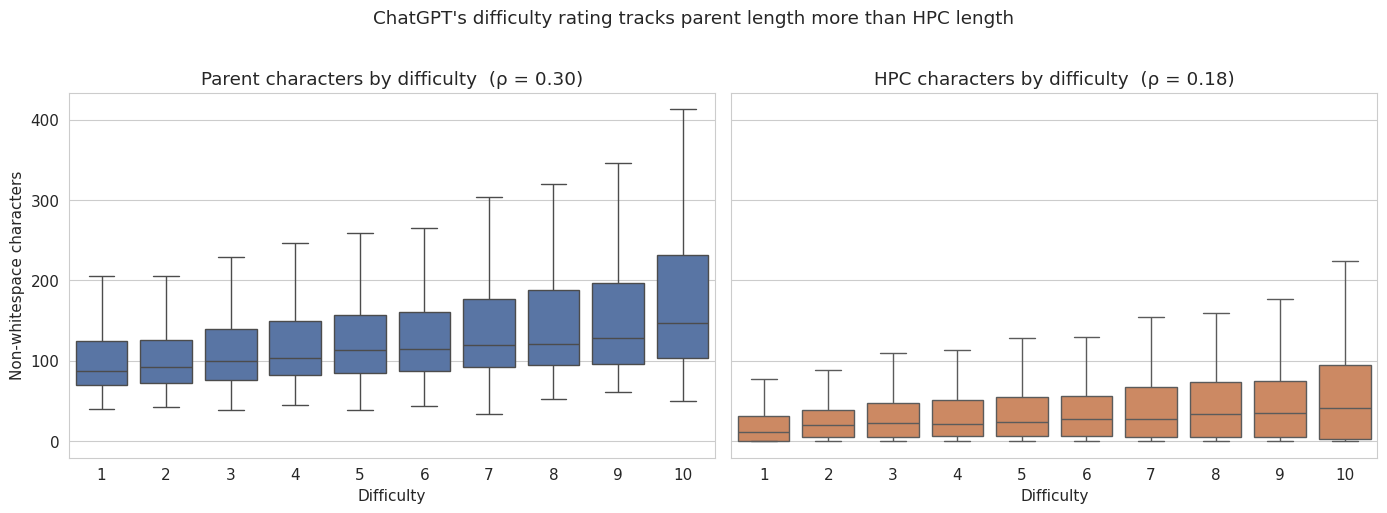

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left: parent
sns.boxplot(data=df, x="question_number", y="parent_chars_nonws",
            color="#4C72B0", showfliers=False, ax=axes[0])
axes[0].set_title("Parent characters by difficulty  (ρ = 0.30)")
axes[0].set_xlabel("Difficulty")
axes[0].set_ylabel("Non-whitespace characters")

# Right: HPC
sns.boxplot(data=df, x="question_number", y="hpc_chars_nonws",
            color="#DD8452", showfliers=False, ax=axes[1])
axes[1].set_title("HPC characters by difficulty  (ρ = 0.18)")
axes[1].set_xlabel("Difficulty")
axes[1].set_ylabel("")

plt.suptitle("ChatGPT's difficulty rating tracks parent length more than HPC length", y=1.02)
plt.tight_layout()
plt.savefig("plot4_parent_vs_hpc.png", dpi=150, bbox_inches="tight")
plt.show()

So far we've pooled all 5 models. Now we ask whether each model uses the same features when assigning difficulty. Three possibilities: identical (difficulty is a property of the question), agree on direction but differ in magnitude (some models lean more on certain features), or genuinely disagree (model "personality" differences).

## Spearman correlations split by model
For each (feature, model) pair, computes the correlation. Result is a feature × model table: the heart of the model-comparison analysis.

In [18]:
from scipy.stats import spearmanr

# Subset of features worth comparing — top performers + a few interesting nulls
key_features = [
    "parent_chars_nonws", "parent_tokens", "parent_max_line_length",
    "parent_pykeywords_cf", "hpc_tokens", "hpc_pykeywords_cf",
    "hpc_max_nesting_depth", "parent_max_nesting_depth",
    "mc_choices_sim_max", "parent_answerchoices_avg_len",
]

# Build a table: rows = features, columns = models, values = Spearman rho
per_model = {}
for model in MODEL_ORDER:
    sub = df[df["model"] == model]
    rhos = {}
    for feat in key_features:
        pair = sub[["question_number", feat]].dropna()
        if len(pair) < 30:
            rhos[feat] = None
            continue
        rho, _ = spearmanr(pair["question_number"], pair[feat])
        rhos[feat] = round(rho, 3)
    per_model[model] = rhos

per_model_df = pd.DataFrame(per_model)
per_model_df = per_model_df[MODEL_ORDER]  # consistent column order

# Add a "pooled" column for reference (all models combined)
pooled = {}
for feat in key_features:
    pair = df[["question_number", feat]].dropna()
    rho, _ = spearmanr(pair["question_number"], pair[feat])
    pooled[feat] = round(rho, 3)
per_model_df["POOLED"] = pd.Series(pooled)

per_model_df

,gpt-4o-mini,gpt-4o,o1-mini,o1,o3-mini,POOLED
parent_chars_nonws,0.269,0.342,0.325,0.278,0.365,0.303
parent_tokens,0.233,0.291,0.290,0.237,0.342,0.266
parent_max_line_length,0.235,0.287,0.256,0.258,0.299,0.252
parent_pykeywords_cf,0.133,0.247,0.184,0.171,0.256,0.195
hpc_tokens,0.143,0.172,0.224,0.205,0.252,0.196
hpc_pykeywords_cf,0.126,0.182,0.175,0.183,0.231,0.179
hpc_max_nesting_depth,-0.034,-0.056,-0.001,0.016,0.004,-0.014
parent_max_nesting_depth,0.075,0.106,0.159,0.096,0.155,0.115
mc_choices_sim_max,-0.008,0.017,0.022,0.050,0.052,0.028
parent_answerchoices_avg_len,0.013,0.030,0.028,0.045,0.018,0.027


## Heatmap of per-model correlations
Visualizes the table from the previous cell. Rows uniformly red across all columns = features every model relies on. Mixed-color rows = features where models disagree.

**Finding:** All models broadly agree on direction: no row goes positive for some models and negative for others. But magnitudes vary systematically. o3-mini's difficulty ratings correlate most strongly with surface features (top of the heatmap is darkest red on its column); gpt-4o-mini's correlations are consistently weakest. Two interpretations: (a) o3-mini ties difficulty more reliably to measurable code/text complexity, (b) gpt-4o-mini relies on features not captured in this dataset.

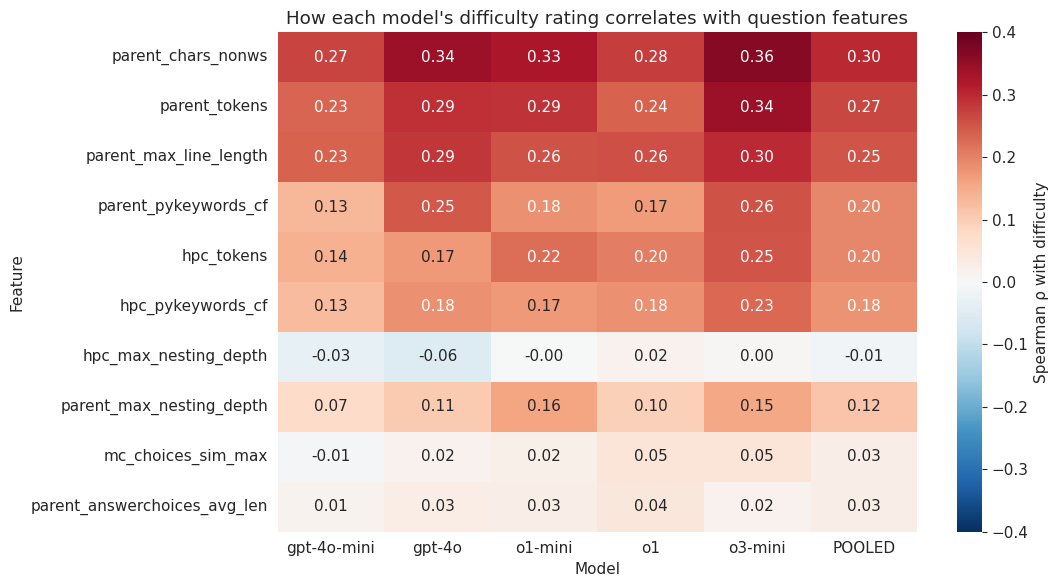

In [19]:
plt.figure(figsize=(11, 6))
sns.heatmap(
    per_model_df.astype(float),
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-0.4, vmax=0.4,
    cbar_kws={"label": "Spearman ρ with difficulty"}
)
plt.title("How each model's difficulty rating correlates with question features")
plt.xlabel("Model")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("plot5_per_model_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Feature-to-feature correlation analysis

Before running multivariate regression, we need to know which features are redundant. Throwing 28+ features into an OLS model where many are essentially measuring the same thing (e.g., line count and character count) inflates standard errors, makes coefficients unstable, and breaks AIC/BIC selection. This section finds the redundancy clusters and produces a lean feature list ready for regression.

## Build the analysis-ready feature list
Pulls together every numeric complexity feature we want to test for redundancy. Drops the four operator columns (broken, all zeros) and keeps `question_number` separate so we can use it as the difficulty target when choosing representatives later. Also prints a NaN summary so we know which features have missingness issues before we trust the correlation matrix.

In [20]:
# Features to test for redundancy (drops the four broken operator columns)
analysis_features = [
    # HPC code metrics
    "hpc_snippets", "hpc_newlines", "hpc_chars", "hpc_chars_nonws",
    "hpc_pykeywords", "hpc_pykeywords_cf", "hpc_max_nesting_depth",
    "hpc_tokens", "hpc_avg_tokens_per_code_line",
    "hpc_avg_line_length", "hpc_max_line_length",
    # Parent metrics
    "parent_chars", "parent_snippets", "parent_newlines",
    "parent_chars_from_snippets", "parent_chars_nonws",
    "parent_pykeywords", "parent_pykeywords_cf", "parent_max_nesting_depth",
    "parent_tokens", "parent_avg_tokens_per_code_line",
    "parent_avg_line_length", "parent_max_line_length",
    # Question structure
    "parent_answerchoices_count", "parent_answerchoices_avg_len",
    "in_question", "elsewhere", "in_question_chars", "elsewhere_chars",
]

print(f"Total features to test: {len(analysis_features)}")

nan_summary = df[analysis_features].isna().sum().sort_values(ascending=False)
nan_with_data = nan_summary[nan_summary > 0]

print(f"\nNaN counts per feature:")
if len(nan_with_data):
    print(nan_with_data.to_string())
else:
    print("(no NaNs in any analysis feature)")

print(f"\nRows with at least one NaN across analysis features: "
      f"{df[analysis_features].isna().any(axis=1).sum()} of {len(df)}")

Total features to test: 29

NaN counts per feature:
(no NaNs in any analysis feature)

Rows with at least one NaN across analysis features: 0 of 4001


## Compute the feature-to-feature Spearman correlation matrix
Spearman because the same logic from the difficulty correlations applies here: many features are bounded at zero, distributions are skewed, and we care about monotonic relationships rather than strictly linear ones. Includes `question_number` as the first row/column so we can see each feature's relationship to difficulty alongside its relationship to other features. Pandas `.corr` handles NaN pairwise.

In [21]:
# Include question_number so we can see each feature's relationship to difficulty
# alongside its relationship to other features
matrix_cols = ["question_number"] + analysis_features
corr_matrix = df[matrix_cols].corr(method="spearman")

# Save the raw matrix
corr_matrix.to_csv("feature_feature_spearman.csv")
print(f"Matrix shape: {corr_matrix.shape}")
print(f"Saved feature_feature_spearman.csv")
print(f"\nDiagonal sanity check (should all be 1.00): {corr_matrix.values.diagonal()[:5]}...")

Matrix shape: (30, 30)
Saved feature_feature_spearman.csv

Diagonal sanity check (should all be 1.00): [1. 1. 1. 1. 1.]...


## Heatmap: features ordered by category
The basic visual. Features are grouped by source (parent vs HPC vs structure) so you can see where redundancy clusters live. Top row and left column = correlation with `question_number` (the difficulty target). Inside the matrix, dark red = highly correlated pair (likely redundant); dark blue = strongly inversely correlated; near-white = independent.

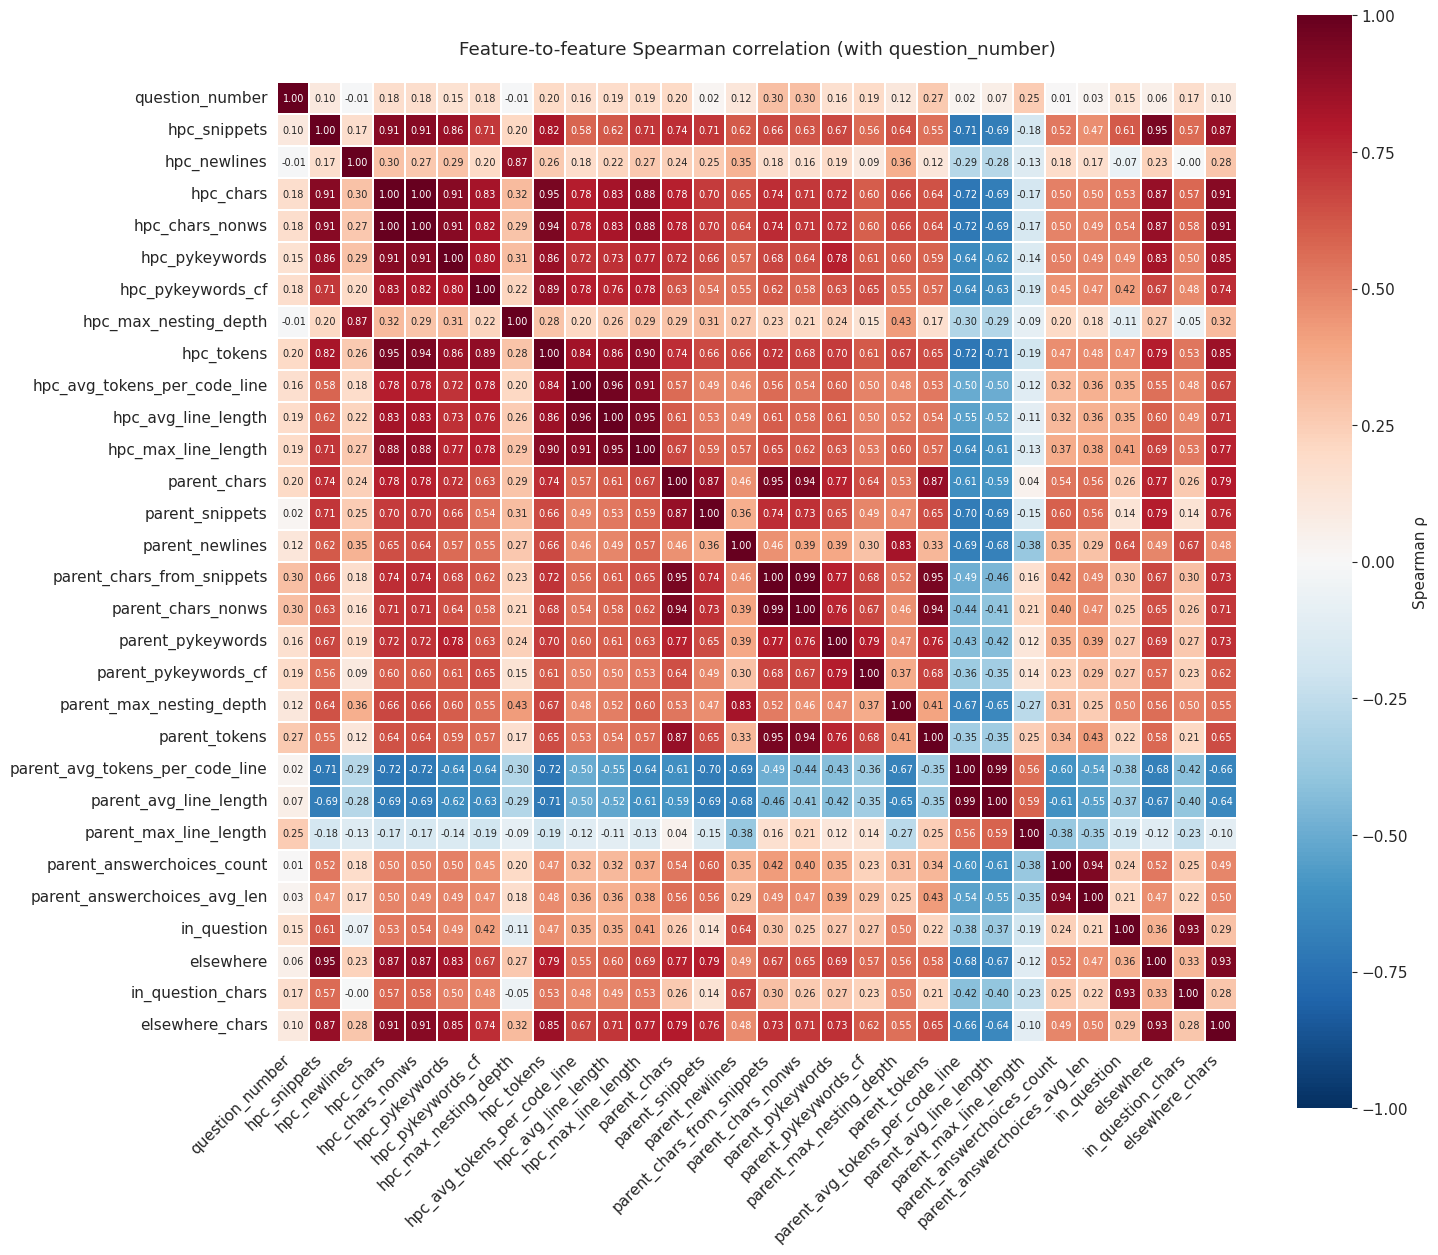

In [22]:
plt.figure(figsize=(15, 13))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot_kws={"size": 7},
    cbar_kws={"label": "Spearman ρ"},
    square=True,
    linewidths=0.3,
    linecolor="white",
)
plt.title("Feature-to-feature Spearman correlation (with question_number)", pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("plot_feature_heatmap_categorical.png", dpi=150, bbox_inches="tight")
plt.show()

## Clustermap: hierarchical clustering reveals redundancy blocks
Same data as the previous heatmap, but rows and columns are reordered by hierarchical clustering on `1 - |ρ|` distance. Highly correlated features end up adjacent, so redundancy shows up as block-diagonal structure. We use average linkage, the conventional default for correlation-based feature clustering. The dendrograms on the top and left show how features group together at different similarity thresholds. This is the main visual deliverable of this section.

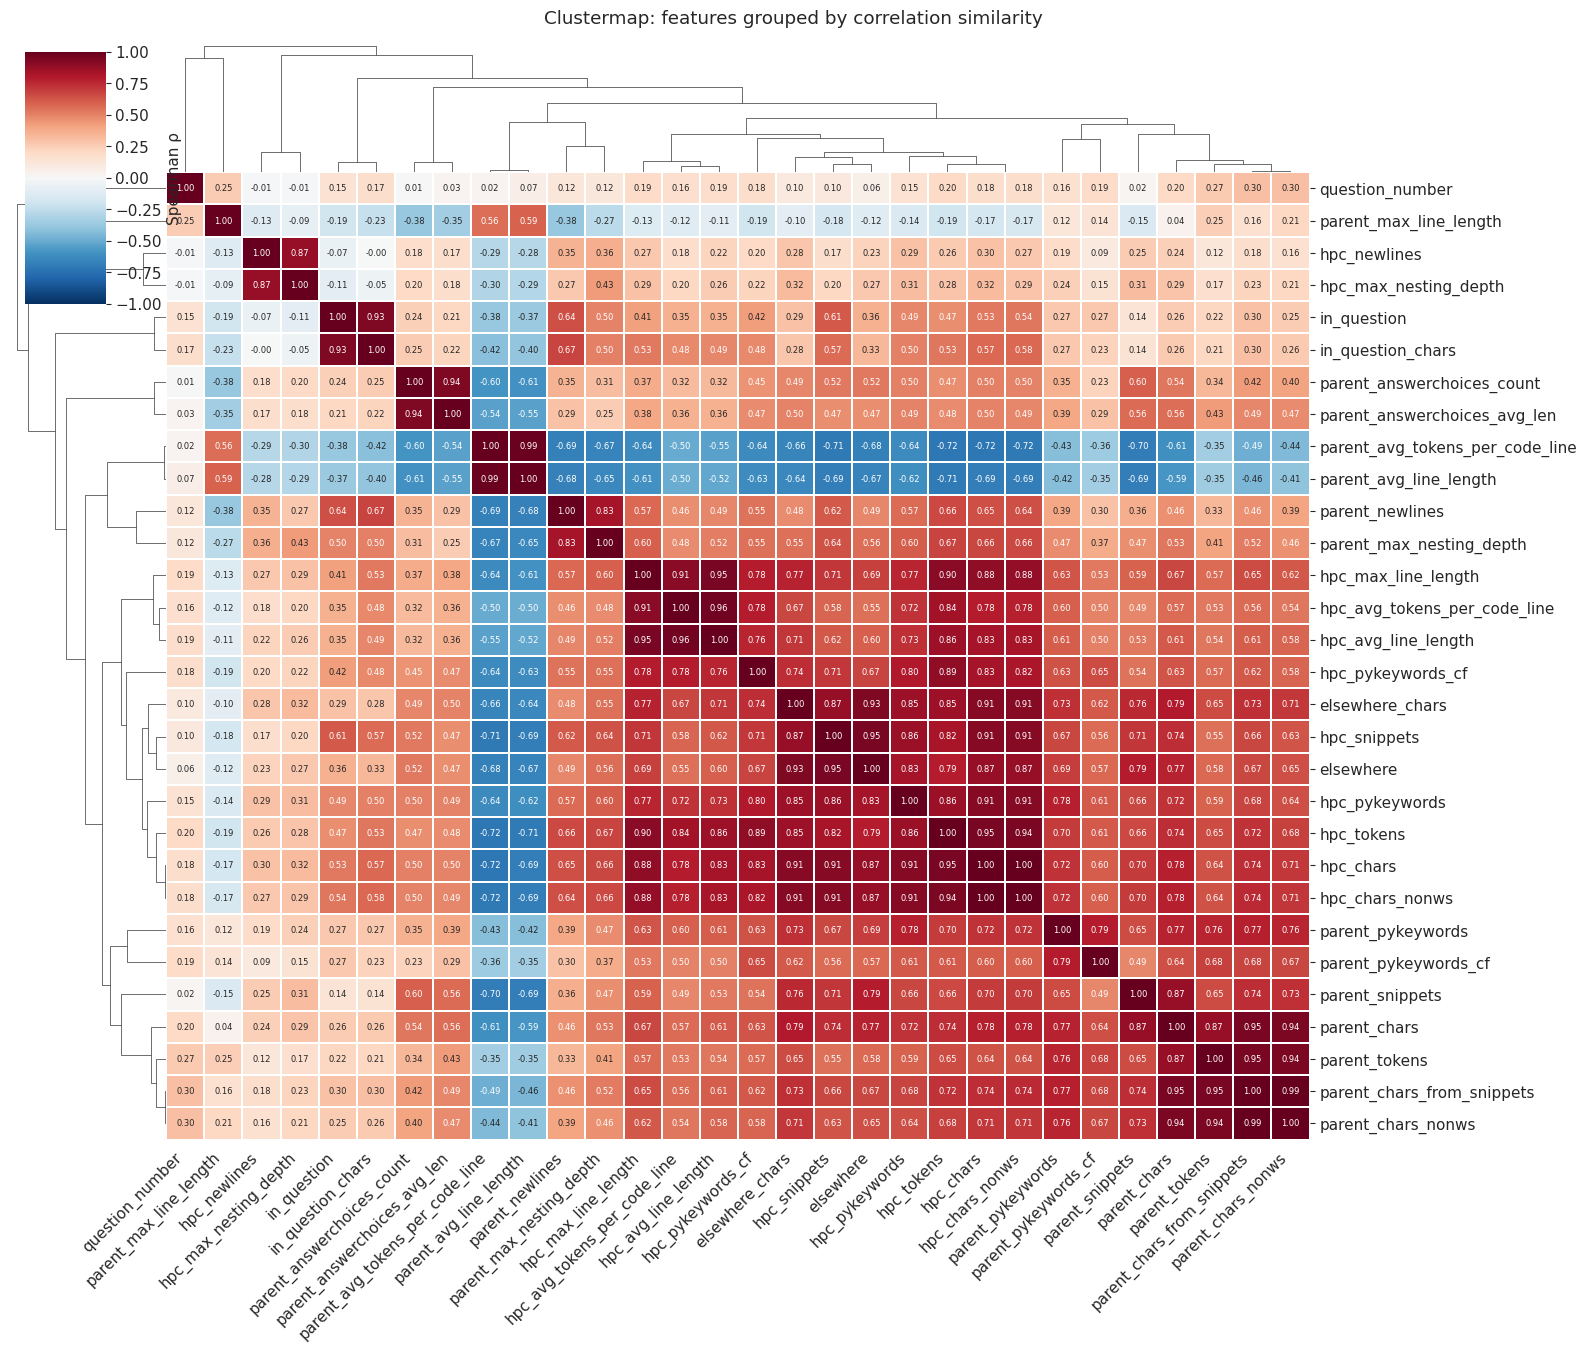

In [23]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage

# Distance = 1 - |ρ|. Two perfectly correlated features have distance 0; uncorrelated have distance 1.
dist_matrix = 1 - corr_matrix.abs()
np.fill_diagonal(dist_matrix.values, 0)  # ensure exact zero on diagonal

# Convert to condensed form for scipy
condensed = squareform(dist_matrix.values, checks=False)
row_linkage = linkage(condensed, method="average")

g = sns.clustermap(
    corr_matrix,
    row_linkage=row_linkage,
    col_linkage=row_linkage,
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f",
    annot_kws={"size": 6},
    figsize=(16, 14),
    cbar_kws={"label": "Spearman ρ"},
    dendrogram_ratio=0.12,
    linewidths=0.2,
    linecolor="white",
)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right")
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.fig.suptitle("Clustermap: features grouped by correlation similarity", y=1.01)
plt.savefig("plot_feature_clustermap.png", dpi=150, bbox_inches="tight")
plt.show()

## List highly correlated feature pairs
The concrete output: every pair of features with |ρ| above 0.8, sorted by strength. These are your strongest redundancy candidates. A pair at ρ = 0.95 means the two features are essentially measuring the same thing; including both in a regression adds noise without information.

In [24]:
# Pull just the feature-feature block (drop question_number)
ff_corr = corr_matrix.drop("question_number", axis=0).drop("question_number", axis=1)

# Get upper triangle as a Series of (feat1, feat2) -> rho
mask = np.triu(np.ones(ff_corr.shape, dtype=bool), k=1)
upper = ff_corr.where(mask)
pairs = upper.stack().reset_index()
pairs.columns = ["feature_1", "feature_2", "rho"]
pairs["abs_rho"] = pairs["rho"].abs()
pairs = pairs.sort_values("abs_rho", ascending=False).reset_index(drop=True)

# Threshold for "redundant"
THRESHOLD = 0.8
redundant = pairs[pairs["abs_rho"] >= THRESHOLD]

print(f"Total feature pairs: {len(pairs)}")
print(f"Pairs with |ρ| ≥ {THRESHOLD}: {len(redundant)}")

print(f"\nTop 20 most correlated pairs:")
print(pairs.head(20)[["feature_1", "feature_2", "rho"]].to_string(index=False))

print(f"\nAll redundancy candidates (|ρ| ≥ {THRESHOLD}):")
print(redundant[["feature_1", "feature_2", "rho"]].to_string(index=False))

redundant.to_csv("feature_redundancy_pairs.csv", index=False)
print(f"\nSaved feature_redundancy_pairs.csv")

Total feature pairs: 406
Pairs with |ρ| ≥ 0.8: 45

Top 20 most correlated pairs:
                      feature_1                    feature_2      rho
                      hpc_chars              hpc_chars_nonws 0.997591
     parent_chars_from_snippets           parent_chars_nonws 0.992923
parent_avg_tokens_per_code_line       parent_avg_line_length 0.987332
   hpc_avg_tokens_per_code_line          hpc_avg_line_length 0.963199
            hpc_avg_line_length          hpc_max_line_length 0.950676
                      hpc_chars                   hpc_tokens 0.948469
                   parent_chars   parent_chars_from_snippets 0.947376
     parent_chars_from_snippets                parent_tokens 0.946102
                   hpc_snippets                    elsewhere 0.945404
             parent_chars_nonws                parent_tokens 0.943602
                hpc_chars_nonws                   hpc_tokens 0.943428
                   parent_chars           parent_chars_nonws 0.939954
     pare

## Sensitivity check: how does the cluster count depend on the threshold?
Before committing to |ρ| ≥ 0.8 as the redundancy cutoff, sweep through a range of thresholds and see how many clusters fall out at each. This is a sanity check: if the cluster count is wildly sensitive (e.g., flips from 10 to 30 between |ρ| = 0.7 and |ρ| = 0.8), the choice of threshold matters a lot. If it's stable across the range, we can be more confident in the chosen value.

 rho_threshold  n_clusters  n_features_kept
          0.50           6                6
          0.55           7                7
          0.60           7                7
          0.65           8                8
          0.70          10               10
          0.75          11               11
          0.80          14               14
          0.85          15               15
          0.90          18               18
          0.95          26               26


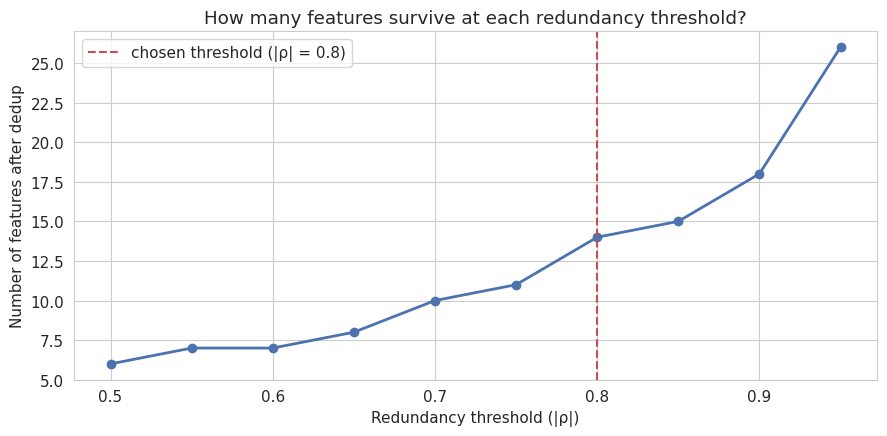

In [25]:
from scipy.cluster.hierarchy import fcluster

thresholds = np.arange(0.5, 1.0, 0.05)  # |ρ| from 0.5 to 0.95
results = []
for rho_threshold in thresholds:
    dist_threshold = 1 - rho_threshold
    cids = fcluster(row_linkage, t=dist_threshold, criterion="distance")
    results.append({
        "rho_threshold": round(rho_threshold, 2),
        "n_clusters": len(set(cids)),
        "n_features_kept": len(set(cids)),  # one rep per cluster
    })

sweep_df = pd.DataFrame(results)
print(sweep_df.to_string(index=False))

plt.figure(figsize=(9, 4.5))
plt.plot(sweep_df["rho_threshold"], sweep_df["n_features_kept"],
         marker="o", color="#4C72B0", linewidth=2)
plt.axvline(0.8, color="#C44E52", linestyle="--", linewidth=1.5,
            label="chosen threshold (|ρ| = 0.8)")
plt.xlabel("Redundancy threshold (|ρ|)")
plt.ylabel("Number of features after dedup")
plt.title("How many features survive at each redundancy threshold?")
plt.legend()
plt.tight_layout()
plt.savefig("plot_threshold_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

## Cluster features at the redundancy threshold and pick representatives
Cuts the dendrogram at distance 0.2, which corresponds to |ρ| = 0.8 in the linkage tree. The |ρ| ≥ 0.8 threshold is a widely-used convention for treating features as redundant in regression contexts. Features that cluster together are treated as redundant. For each cluster, pick the single feature that correlates most strongly with `question_number`, since that's the one most useful for predicting difficulty. Singleton clusters (features with no strong twin) pass through unchanged. The result is a "lean" feature list ready for regression.

In [26]:
# Build linkage on features ONLY (exclude question_number, which is our target)
ff_dist = 1 - ff_corr.abs()
np.fill_diagonal(ff_dist.values, 0)
ff_condensed = squareform(ff_dist.values, checks=False)
ff_linkage = linkage(ff_condensed, method="average")

# Cut the dendrogram at distance threshold (|ρ| = 0.8 → distance = 0.2)
DIST_THRESHOLD = 0.2
cluster_ids = fcluster(ff_linkage, t=DIST_THRESHOLD, criterion="distance")

# Map each feature to its cluster ID
feature_clusters = pd.DataFrame({
    "feature": ff_corr.index,
    "cluster": cluster_ids,
})

# For ranking: each feature's |correlation with question_number|
diff_corr = corr_matrix["question_number"].drop("question_number").abs()
feature_clusters["abs_rho_with_difficulty"] = (
    feature_clusters["feature"].map(diff_corr).round(3)
)

# For each cluster, pick the feature with the strongest difficulty correlation
representatives = (
    feature_clusters
    .sort_values("abs_rho_with_difficulty", ascending=False)
    .groupby("cluster", as_index=False)
    .first()
)

print(f"Number of clusters at distance {DIST_THRESHOLD} (|ρ| ≥ {1 - DIST_THRESHOLD:.1f}): "
      f"{feature_clusters['cluster'].nunique()}")
print(f"Original feature count: {len(feature_clusters)}")
print(f"Lean feature count after dedup: {len(representatives)}")

print(f"\nClusters and their representatives:")
print("=" * 80)
for cid in sorted(feature_clusters["cluster"].unique()):
    members = feature_clusters[feature_clusters["cluster"] == cid].sort_values(
        "abs_rho_with_difficulty", ascending=False
    )
    rep = representatives[representatives["cluster"] == cid].iloc[0]["feature"]
    if len(members) == 1:
        print(f"  Cluster {cid:>2}: {members.iloc[0]['feature']} (singleton)")
    else:
        print(f"  Cluster {cid:>2}: representative = {rep}")
        for _, m in members.iterrows():
            marker = "  ← keep" if m["feature"] == rep else "    drop"
            print(f"          {m['feature']:40s}  ρ_diff = {m['abs_rho_with_difficulty']:.3f}{marker}")
print("=" * 80)

lean_features = sorted(representatives["feature"].tolist())
print(f"\nLean feature list ({len(lean_features)} features):")
for f in lean_features:
    print(f"  {f}")

Number of clusters at distance 0.2 (|ρ| ≥ 0.8): 13
Original feature count: 29
Lean feature count after dedup: 13

Clusters and their representatives:
  Cluster  1: representative = hpc_newlines
          hpc_newlines                              ρ_diff = 0.015  ← keep
          hpc_max_nesting_depth                     ρ_diff = 0.014    drop
  Cluster  2: representative = in_question_chars
          in_question_chars                         ρ_diff = 0.175  ← keep
          in_question                               ρ_diff = 0.150    drop
  Cluster  3: representative = parent_answerchoices_avg_len
          parent_answerchoices_avg_len              ρ_diff = 0.027  ← keep
          parent_answerchoices_count                ρ_diff = 0.007    drop
  Cluster  4: representative = parent_avg_line_length
          parent_avg_line_length                    ρ_diff = 0.069  ← keep
          parent_avg_tokens_per_code_line           ρ_diff = 0.024    drop
  Cluster  5: representative = parent_newli

## Variance Inflation Factor (VIF) on the lean feature list
A second-pass multicollinearity check. The clustering catches pairwise redundancy, but a feature can still be a near-perfect linear combination of three or four others without any individual pair being above the threshold. VIF measures exactly that. Rule of thumb: VIF < 5 is fine, 5 to 10 is concerning, > 10 means the feature is essentially a linear combination of others and should be dropped before OLS. These thresholds are conventions and should be treated as soft guides rather than hard cutoffs.

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF needs no NaN, so drop rows where any lean feature is missing
X = df[lean_features].dropna()
print(f"Rows used for VIF (after dropna): {len(X)} of {len(df)}")

vifs = pd.Series(
    [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    index=X.columns,
    name="VIF",
).sort_values(ascending=False)

print(f"\nVIF for the lean feature set:")
print(vifs.round(2).to_string())

high_vif = vifs[vifs > 5]
if len(high_vif):
    print(f"\nFeatures with VIF > 5 (potential multicollinearity):")
    print(high_vif.round(2).to_string())
    print("\nConsider dropping these (or revisiting cluster representatives) before OLS.")
else:
    print("\nAll VIFs are below 5. Feature set is regression-ready.")

Rows used for VIF (after dropna): 4001 of 4001

VIF for the lean feature set:
parent_chars_nonws              26.90
parent_max_line_length          21.93
parent_pykeywords               15.99
parent_pykeywords_cf            12.20
hpc_tokens                      11.29
parent_avg_line_length           9.56
hpc_pykeywords_cf                8.13
parent_snippets                  6.78
hpc_max_line_length              5.06
in_question_chars                4.31
parent_newlines                  3.74
parent_answerchoices_avg_len     2.40
hpc_newlines                     1.54

Features with VIF > 5 (potential multicollinearity):
parent_chars_nonws        26.90
parent_max_line_length    21.93
parent_pykeywords         15.99
parent_pykeywords_cf      12.20
hpc_tokens                11.29
parent_avg_line_length     9.56
hpc_pykeywords_cf          8.13
parent_snippets            6.78
hpc_max_line_length        5.06

Consider dropping these (or revisiting cluster representatives) before OLS.


## Save the lean feature list and the cluster mapping
Persists the deduplicated feature list as a CSV so the next phase (multivariate regression with AIC/BIC selection) can pick it up directly. Also keeps a copy of the cluster mapping in case you need to argue for a different representative later, or revisit the threshold.

In [28]:
# Save the lean feature list
pd.Series(lean_features, name="feature").to_csv("regression_features_lean.csv", index=False)

# Save the full cluster mapping (which features were grouped together, which got picked)
cluster_mapping = feature_clusters.copy()
cluster_mapping["is_representative"] = cluster_mapping["feature"].isin(lean_features)
cluster_mapping = cluster_mapping.sort_values(
    ["cluster", "abs_rho_with_difficulty"],
    ascending=[True, False],
)
cluster_mapping.to_csv("feature_cluster_mapping.csv", index=False)

print("Saved:")
print(f"  regression_features_lean.csv  ({len(lean_features)} features)")
print(f"  feature_cluster_mapping.csv  (cluster membership for all {len(feature_clusters)} original features)")
print(f"\nReady for multivariate regression in the next phase.")

Saved:
  regression_features_lean.csv  (13 features)
  feature_cluster_mapping.csv  (cluster membership for all 29 original features)

Ready for multivariate regression in the next phase.


# Multivariate linear regression

The Spearman work told us which individual features correlate with difficulty. The redundancy work gave us a deduplicated list. Now the question is: which combination of features best predicts difficulty when used together? OLS gives us coefficients, statistical significance, and goodness-of-fit. AIC/BIC stepwise selection prunes the feature set automatically.

A note on the target: `question_number` is ordinal (1 to 10) and represents rank within a (model, method, subject) group. OLS treats it as continuous, which is a mild stretch but standard practice for this kind of analysis. We address the within-group structure in a later cell by adding model/method/subject as fixed-effect controls.

## Prepare the regression dataset
Loads the lean feature list from the previous section, builds the design matrix `X` and target `y`, drops rows with any missing values, and reports how much data we lose. Two of the lean features (`parent_answerchoices_count`, `parent_answerchoices_avg_len`) are NaN for non-multiple-choice questions, so this drop is non-trivial.

In [29]:
# Load the lean feature list saved in the previous section
lean_features_loaded = pd.read_csv("regression_features_lean.csv")["feature"].tolist()
print(f"Lean features loaded: {len(lean_features_loaded)}")

# Build X and y, drop rows with any NaN
reg_data = df[["question_number"] + lean_features_loaded].dropna()
y = reg_data["question_number"].astype(float)
X = reg_data[lean_features_loaded].astype(float)

print(f"Rows before NaN drop: {len(df)}")
print(f"Rows after NaN drop:  {len(reg_data)}")
print(f"Lost: {len(df) - len(reg_data)} rows ({100 * (len(df) - len(reg_data)) / len(df):.1f}%)")

# Sanity check on the target
print(f"\nTarget (question_number) distribution:")
print(y.value_counts().sort_index())

Lean features loaded: 13
Rows before NaN drop: 4001
Rows after NaN drop:  4001
Lost: 0 rows (0.0%)

Target (question_number) distribution:
question_number
1.0     400
2.0     400
3.0     400
4.0     400
5.0     400
6.0     400
7.0     400
8.0     400
9.0     401
10.0    400
Name: count, dtype: int64


## Standardize the features
Z-scores every feature (mean 0, std 1). Two reasons:

1. Coefficients become directly comparable in magnitude. A coefficient of 0.3 on a standardized feature means "a 1-SD increase in this feature predicts a 0.3-unit increase in difficulty," regardless of whether the original feature was measured in characters, lines, or counts.
2. Stepwise selection compares features on equal footing. Without standardization, larger-scale features can dominate.

The intercept and significance tests are unchanged by standardization; only the coefficient magnitudes shift.

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_std = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index,
)

print("Feature means after standardization (should all be ~0):")
print(X_std.mean().round(3).to_string())
print("\nFeature std after standardization (should all be ~1):")
print(X_std.std().round(3).to_string())

Feature means after standardization (should all be ~0):
hpc_max_line_length            -0.0
hpc_newlines                   -0.0
hpc_pykeywords_cf               0.0
hpc_tokens                      0.0
in_question_chars               0.0
parent_answerchoices_avg_len   -0.0
parent_avg_line_length          0.0
parent_chars_nonws             -0.0
parent_max_line_length         -0.0
parent_newlines                -0.0
parent_pykeywords               0.0
parent_pykeywords_cf            0.0
parent_snippets                 0.0

Feature std after standardization (should all be ~1):
hpc_max_line_length             1.0
hpc_newlines                    1.0
hpc_pykeywords_cf               1.0
hpc_tokens                      1.0
in_question_chars               1.0
parent_answerchoices_avg_len    1.0
parent_avg_line_length          1.0
parent_chars_nonws              1.0
parent_max_line_length          1.0
parent_newlines                 1.0
parent_pykeywords               1.0
parent_pykeywords_cf     

## Baseline: OLS with all lean features
Fits a single OLS model using every lean feature at once. This is the "kitchen sink" baseline: the upper bound on R² we can extract from this feature set without adding interactions, polynomial terms, or non-numeric controls. The coefficients and p-values tell us which features pull weight when all of them compete.

In [31]:
import statsmodels.api as sm

X_full = sm.add_constant(X_std)
ols_full = sm.OLS(y, X_full).fit()
print(ols_full.summary())

print(f"\nQuick read of the headlines:")
print(f"  R²:           {ols_full.rsquared:.4f}")
print(f"  Adj R²:       {ols_full.rsquared_adj:.4f}")
print(f"  AIC:          {ols_full.aic:.1f}")
print(f"  BIC:          {ols_full.bic:.1f}")
print(f"  F-stat p:     {ols_full.f_pvalue:.2e}")
print(f"  N:            {int(ols_full.nobs)}")

                            OLS Regression Results                            
Dep. Variable:        question_number   R-squared:                       0.226
Model:                            OLS   Adj. R-squared:                  0.223
Method:                 Least Squares   F-statistic:                     89.46
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          3.59e-210
Time:                        20:39:41   Log-Likelihood:                -9386.9
No. Observations:                4001   AIC:                         1.880e+04
Df Residuals:                    3987   BIC:                         1.889e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

## Stepwise selection helpers
Standard implementation of forward and backward stepwise selection. At each step:

- **Forward**: starts with no features, adds the feature that lowers the criterion the most. Stops when no addition improves it.
- **Backward**: starts with all features, removes the feature whose removal lowers the criterion the most. Stops when no removal improves it.

AIC and BIC penalize complexity differently. BIC has a heavier penalty for additional features (proportional to log of sample size), so it tends to pick smaller, more conservative models. AIC is more permissive and tends to pick larger ones. Running both gives us a sense of whether the answer is robust to the choice of criterion.

A methodological caveat worth noting: stepwise selection is known to inflate the apparent significance of selected features and to be unstable under resampling. Regularization-based alternatives such as LASSO avoid these issues, but were deferred for this phase. AIC and BIC stepwise give a reasonable starting feature set for this exploratory analysis.

In [32]:
def stepwise_forward(X, y, criterion="aic", verbose=False):
    selected = []
    remaining = list(X.columns)
    current_score = np.inf

    while remaining:
        scores = {}
        for col in remaining:
            feats = selected + [col]
            model = sm.OLS(y, sm.add_constant(X[feats])).fit()
            scores[col] = model.aic if criterion == "aic" else model.bic
        best = min(scores, key=scores.get)
        if scores[best] < current_score:
            selected.append(best)
            remaining.remove(best)
            current_score = scores[best]
            if verbose:
                print(f"  + {best:40s}  {criterion.upper()} = {current_score:.2f}")
        else:
            break
    return selected, current_score


def stepwise_backward(X, y, criterion="aic", verbose=False):
    selected = list(X.columns)
    current_score = (
        sm.OLS(y, sm.add_constant(X[selected])).fit().aic
        if criterion == "aic"
        else sm.OLS(y, sm.add_constant(X[selected])).fit().bic
    )

    while len(selected) > 1:
        scores = {}
        for col in selected:
            feats = [c for c in selected if c != col]
            model = sm.OLS(y, sm.add_constant(X[feats])).fit()
            scores[col] = model.aic if criterion == "aic" else model.bic
        worst = min(scores, key=scores.get)
        if scores[worst] < current_score:
            selected.remove(worst)
            current_score = scores[worst]
            if verbose:
                print(f"  - {worst:40s}  {criterion.upper()} = {current_score:.2f}")
        else:
            break
    return selected, current_score


print("Stepwise selection functions defined.")

Stepwise selection functions defined.


## Run forward and backward selection with both criteria
Four model variants. If forward AIC and backward AIC converge to the same feature set, we have strong evidence that's the AIC-optimal model. Same for BIC. If they disagree (which can happen with correlated features even after dedup), the disagreement itself is informative.

In [33]:
print("Forward stepwise (AIC):")
fwd_aic, fwd_aic_score = stepwise_forward(X_std, y, criterion="aic", verbose=True)
print(f"\nFinal AIC: {fwd_aic_score:.2f}, features kept: {len(fwd_aic)}")

print("\nBackward stepwise (AIC):")
bwd_aic, bwd_aic_score = stepwise_backward(X_std, y, criterion="aic", verbose=True)
print(f"\nFinal AIC: {bwd_aic_score:.2f}, features kept: {len(bwd_aic)}")

print("\nForward stepwise (BIC):")
fwd_bic, fwd_bic_score = stepwise_forward(X_std, y, criterion="bic", verbose=True)
print(f"\nFinal BIC: {fwd_bic_score:.2f}, features kept: {len(fwd_bic)}")

print("\nBackward stepwise (BIC):")
bwd_bic, bwd_bic_score = stepwise_backward(X_std, y, criterion="bic", verbose=True)
print(f"\nFinal BIC: {bwd_bic_score:.2f}, features kept: {len(bwd_bic)}")

Forward stepwise (AIC):
  + parent_chars_nonws                        AIC = 19448.95
  + parent_avg_line_length                    AIC = 19267.27
  + in_question_chars                         AIC = 18982.98
  + parent_max_line_length                    AIC = 18928.79
  + parent_newlines                           AIC = 18890.21
  + parent_pykeywords                         AIC = 18863.59
  + hpc_pykeywords_cf                         AIC = 18821.99
  + hpc_max_line_length                       AIC = 18800.33
  + parent_pykeywords_cf                      AIC = 18798.68
  + parent_snippets                           AIC = 18798.48

Final AIC: 18798.48, features kept: 10

Backward stepwise (AIC):
  - hpc_tokens                                AIC = 18799.87
  - parent_answerchoices_avg_len              AIC = 18798.92
  - hpc_newlines                              AIC = 18798.48

Final AIC: 18798.48, features kept: 10

Forward stepwise (BIC):
  + parent_chars_nonws                        BIC = 

## Compare candidate models side by side
Five candidate models: the kitchen-sink baseline plus the four stepwise variants. The table compares them on adjusted R² (fit), AIC and BIC (penalized fit), and feature count (parsimony). The model with the lowest BIC and a competitive adjusted R² is usually the best practical answer.

In [34]:
def fit_and_score(features, label):
    model = sm.OLS(y, sm.add_constant(X_std[features])).fit()
    return {
        "model": label,
        "n_features": len(features),
        "adj_r2": round(model.rsquared_adj, 4),
        "r2": round(model.rsquared, 4),
        "aic": round(model.aic, 1),
        "bic": round(model.bic, 1),
        "features": features,
    }

candidates = [
    fit_and_score(list(X_std.columns), "Full (all lean)"),
    fit_and_score(fwd_aic, "Forward AIC"),
    fit_and_score(bwd_aic, "Backward AIC"),
    fit_and_score(fwd_bic, "Forward BIC"),
    fit_and_score(bwd_bic, "Backward BIC"),
]

candidates_df = pd.DataFrame(candidates)
print("Candidate model comparison:")
print(candidates_df[["model", "n_features", "adj_r2", "aic", "bic"]].to_string(index=False))

print("\nFeatures kept by each stepwise model:")
for c in candidates[1:]:
    print(f"\n  {c['model']} ({c['n_features']} features):")
    for f in c["features"]:
        print(f"    - {f}")

candidates_df.drop(columns=["features"]).to_csv("regression_model_comparison.csv", index=False)
print("\nSaved regression_model_comparison.csv")

Candidate model comparison:
          model  n_features  adj_r2     aic     bic
Full (all lean)          13  0.2233 18801.8 18889.9
    Forward AIC          10  0.2233 18798.5 18867.7
   Backward AIC          10  0.2233 18798.5 18867.7
    Forward BIC           8  0.2226 18800.3 18857.0
   Backward BIC           8  0.2226 18800.3 18857.0

Features kept by each stepwise model:

  Forward AIC (10 features):
    - parent_chars_nonws
    - parent_avg_line_length
    - in_question_chars
    - parent_max_line_length
    - parent_newlines
    - parent_pykeywords
    - hpc_pykeywords_cf
    - hpc_max_line_length
    - parent_pykeywords_cf
    - parent_snippets

  Backward AIC (10 features):
    - hpc_max_line_length
    - hpc_pykeywords_cf
    - in_question_chars
    - parent_avg_line_length
    - parent_chars_nonws
    - parent_max_line_length
    - parent_newlines
    - parent_pykeywords
    - parent_pykeywords_cf
    - parent_snippets

  Forward BIC (8 features):
    - parent_chars_nonws
  

## Cross-check: does adding model/method/subject change the story?
Adds dummy variables for model (5 levels), method (4 levels), and subject (2 levels) on top of the lean numeric features. If the numeric feature coefficients change a lot when these are added, it means we were partly picking up between-group variation rather than within-group prediction. If they barely move, the feature effects are robust to group identity.

This is a fixed-effects style control, not a causal claim. The point is just to see how stable the answer is.

In [35]:
# Build dummies for the categorical columns
dummies = pd.get_dummies(
    df.loc[reg_data.index, ["model", "method", "subject"]],
    drop_first=True,  # avoid the dummy variable trap
).astype(float)

# Standardize numeric features and concatenate with dummies (dummies stay 0/1)
X_extended = pd.concat([X_std, dummies], axis=1)
X_extended_const = sm.add_constant(X_extended)

ols_extended = sm.OLS(y, X_extended_const).fit()
print(f"Extended model (lean features + categorical controls):")
print(f"  R²:        {ols_extended.rsquared:.4f}")
print(f"  Adj R²:    {ols_extended.rsquared_adj:.4f}")
print(f"  AIC:       {ols_extended.aic:.1f}")
print(f"  BIC:       {ols_extended.bic:.1f}")
print(f"  Features:  {X_extended.shape[1]}")

# Compare numeric feature coefficients: lean only vs lean + controls
coef_compare = pd.DataFrame({
    "lean_only": ols_full.params.drop("const"),
    "with_controls": ols_extended.params[X_std.columns],
})
coef_compare["abs_change"] = (coef_compare["with_controls"] - coef_compare["lean_only"]).abs()
coef_compare = coef_compare.sort_values("abs_change", ascending=False)

print(f"\nCoefficient stability check (top movers):")
print(coef_compare.round(3).head(10).to_string())

Extended model (lean features + categorical controls):
  R²:        0.2565
  Adj R²:    0.2525
  AIC:       18656.1
  BIC:       18794.6
  Features:  21

Coefficient stability check (top movers):
                              lean_only  with_controls  abs_change
parent_avg_line_length            0.644          0.380       0.263
parent_snippets                  -0.135          0.119       0.254
hpc_max_line_length               0.277          0.435       0.158
parent_max_line_length            0.562          0.688       0.126
hpc_tokens                       -0.035         -0.154       0.119
parent_pykeywords                -0.454         -0.365       0.088
parent_chars_nonws                1.008          1.085       0.077
parent_newlines                   0.417          0.472       0.055
parent_answerchoices_avg_len     -0.060         -0.017       0.043
hpc_pykeywords_cf                 0.427          0.455       0.028


## Pick a winner and show the full summary
The two natural choices are the AIC winner (best balance of fit and parsimony by Akaike's criterion) and the BIC winner (more aggressive pruning). Both are reasonable. We'll show the full summary for each so you can read the coefficients, standard errors, and significance directly.

In [36]:
# Pick the lowest-AIC and lowest-BIC models from candidates
aic_winner = min(candidates, key=lambda c: c["aic"])
bic_winner = min(candidates, key=lambda c: c["bic"])

print(f"AIC winner: {aic_winner['model']} ({aic_winner['n_features']} features)")
print(f"BIC winner: {bic_winner['model']} ({bic_winner['n_features']} features)")

# Refit and print summaries
final_aic_model = sm.OLS(y, sm.add_constant(X_std[aic_winner["features"]])).fit()
final_bic_model = sm.OLS(y, sm.add_constant(X_std[bic_winner["features"]])).fit()

print("\n" + "=" * 80)
print("AIC WINNER FULL SUMMARY")
print("=" * 80)
print(final_aic_model.summary())

print("\n" + "=" * 80)
print("BIC WINNER FULL SUMMARY")
print("=" * 80)
print(final_bic_model.summary())

AIC winner: Forward AIC (10 features)
BIC winner: Forward BIC (8 features)

AIC WINNER FULL SUMMARY
                            OLS Regression Results                            
Dep. Variable:        question_number   R-squared:                       0.225
Model:                            OLS   Adj. R-squared:                  0.223
Method:                 Least Squares   F-statistic:                     116.0
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          1.18e-212
Time:                        20:39:42   Log-Likelihood:                -9388.2
No. Observations:                4001   AIC:                         1.880e+04
Df Residuals:                    3990   BIC:                         1.887e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------

## Diagnostics: are OLS assumptions being met?
Four-panel diagnostic. We're checking:

1. **Residuals vs fitted**: should look like noise around zero. A funnel shape means heteroskedasticity (variance changes with predictions). A curve means we're missing nonlinearity.
2. **Q-Q plot**: residuals should fall on the diagonal. Heavy tails or curvature mean residuals aren't normal, which mostly affects p-value reliability, less so coefficient estimates.
3. **Scale-location**: |residuals| vs fitted. Flat = constant variance. Trending = heteroskedasticity.
4. **Histogram of residuals**: should look roughly normal.

We expect some failures here because difficulty is ordinal (1 to 10), not continuous. The residuals will be discrete-ish. The point isn't to declare OLS perfectly justified; it's to know what we're working with.

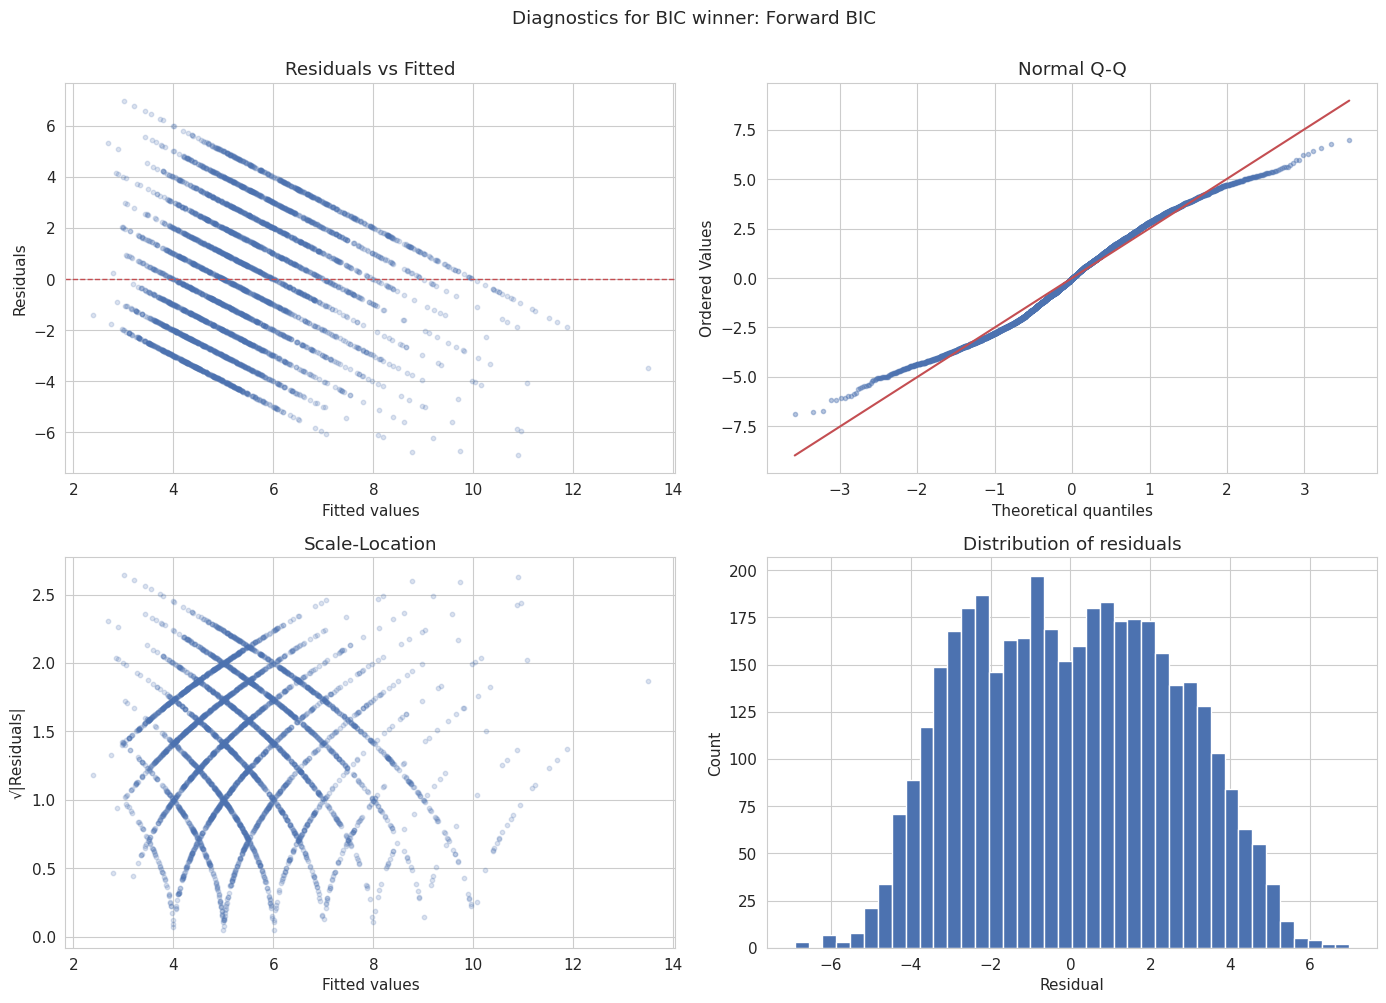

In [37]:
from scipy import stats

# Use the BIC winner for diagnostics (more parsimonious, easier to interpret)
final_model = final_bic_model
fitted = final_model.fittedvalues
residuals = final_model.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs fitted
axes[0, 0].scatter(fitted, residuals, alpha=0.2, s=10, color="#4C72B0")
axes[0, 0].axhline(0, color="#C44E52", linestyle="--", linewidth=1)
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted")

# 2. Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Normal Q-Q")
axes[0, 1].get_lines()[0].set_markerfacecolor("#4C72B0")
axes[0, 1].get_lines()[0].set_markeredgecolor("#4C72B0")
axes[0, 1].get_lines()[0].set_markersize(3)
axes[0, 1].get_lines()[0].set_alpha(0.4)
axes[0, 1].get_lines()[1].set_color("#C44E52")

# 3. Scale-location
sqrt_abs_resid = np.sqrt(np.abs(residuals))
axes[1, 0].scatter(fitted, sqrt_abs_resid, alpha=0.2, s=10, color="#4C72B0")
axes[1, 0].set_xlabel("Fitted values")
axes[1, 0].set_ylabel("√|Residuals|")
axes[1, 0].set_title("Scale-Location")

# 4. Histogram of residuals
axes[1, 1].hist(residuals, bins=40, color="#4C72B0", edgecolor="white")
axes[1, 1].set_xlabel("Residual")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Distribution of residuals")

plt.suptitle(f"Diagnostics for BIC winner: {bic_winner['model']}", y=1.00)
plt.tight_layout()
plt.savefig("plot_regression_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

## Predicted vs actual difficulty
With R² = 0.225 (AIC winner) and Adj R² = 0.223, the cloud will be wide but noticeably tighter than expected for an ordinal target. The regression line will still be flatter than the diagonal, reflecting that the model explains roughly 22% of the variance in difficulty. That's not a bug; it's an honest picture of what this feature set can do.

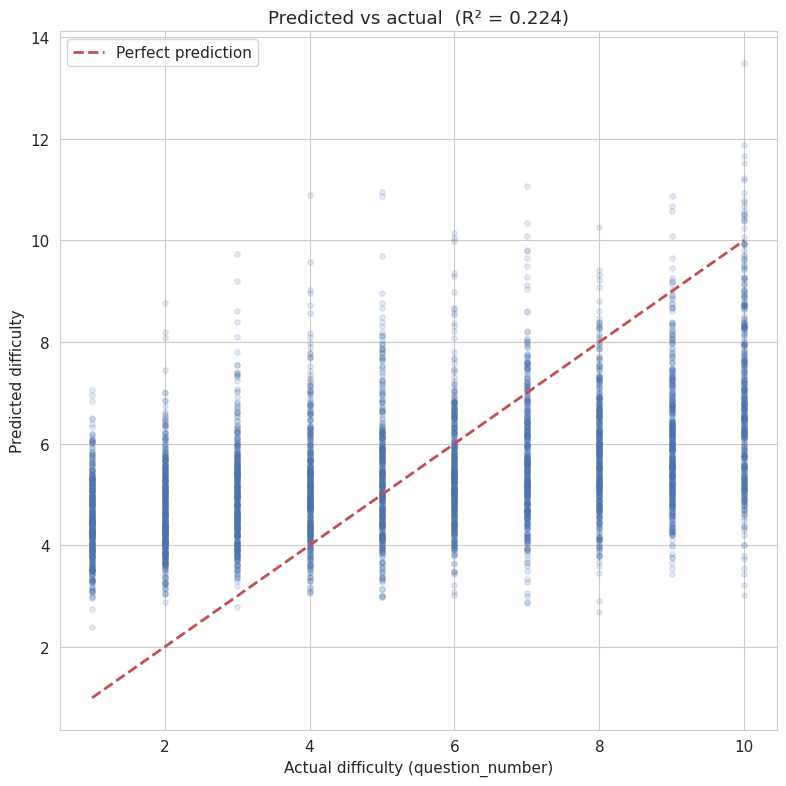

In [38]:
plt.figure(figsize=(8, 8))
plt.scatter(y, fitted, alpha=0.15, s=15, color="#4C72B0")
plt.plot([y.min(), y.max()], [y.min(), y.max()],
         color="#C44E52", linestyle="--", linewidth=2, label="Perfect prediction")
plt.xlabel("Actual difficulty (question_number)")
plt.ylabel("Predicted difficulty")
plt.title(f"Predicted vs actual  (R² = {final_model.rsquared:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig("plot_predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

## Coefficient plot for the winning model
Horizontal bar plot of the standardized coefficients with 95% confidence intervals. Bars that don't cross zero are statistically significant predictors. Bar magnitude shows effect size: how much a 1-SD increase in the feature shifts predicted difficulty. Color indicates direction: blue = positive (more of this feature → harder question), orange = negative.

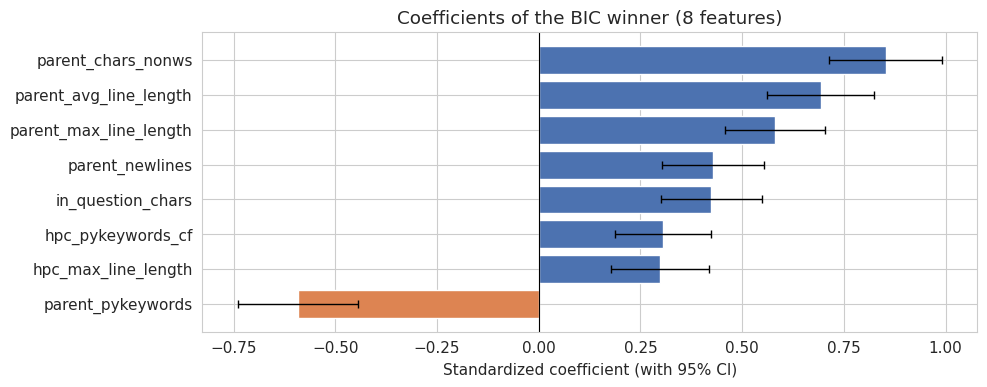

In [39]:
coefs = final_model.params.drop("const")
ci = final_model.conf_int().drop("const")
ci.columns = ["lo", "hi"]

plot_df = pd.concat([coefs.rename("coef"), ci], axis=1)
plot_df = plot_df.sort_values("coef")

colors = ["#DD8452" if c < 0 else "#4C72B0" for c in plot_df["coef"]]

plt.figure(figsize=(10, max(4, 0.4 * len(plot_df))))
y_pos = range(len(plot_df))
plt.barh(y_pos, plot_df["coef"], color=colors,
         xerr=[plot_df["coef"] - plot_df["lo"], plot_df["hi"] - plot_df["coef"]],
         error_kw={"ecolor": "black", "capsize": 3, "linewidth": 1})
plt.axvline(0, color="black", linewidth=0.8)
plt.yticks(y_pos, plot_df.index)
plt.xlabel("Standardized coefficient (with 95% CI)")
plt.title(f"Coefficients of the BIC winner ({len(plot_df)} features)")
plt.tight_layout()
plt.savefig("plot_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

## Save the final model
Persists the winning feature lists, the candidate comparison, and the final coefficient tables. These are the deliverables for this phase: the answer to "what combination of features best predicts difficulty?" in a form ready to hand to Lopez or to plug into the next analysis.

In [40]:
# Final feature lists
pd.Series(aic_winner["features"], name="feature").to_csv(
    "regression_features_aic.csv", index=False
)
pd.Series(bic_winner["features"], name="feature").to_csv(
    "regression_features_bic.csv", index=False
)

# Coefficient tables for both winners
def coef_table(model, label):
    out = pd.DataFrame({
        "coefficient": model.params,
        "std_error": model.bse,
        "t_stat": model.tvalues,
        "p_value": model.pvalues,
        "ci_low": model.conf_int()[0],
        "ci_high": model.conf_int()[1],
    }).round(4)
    out.index.name = "feature"
    return out

coef_table(final_aic_model, "AIC").to_csv("regression_coefs_aic.csv")
coef_table(final_bic_model, "BIC").to_csv("regression_coefs_bic.csv")

print("Saved:")
print("  regression_features_aic.csv")
print("  regression_features_bic.csv")
print("  regression_coefs_aic.csv")
print("  regression_coefs_bic.csv")
print("  regression_model_comparison.csv  (from earlier cell)")

print(f"\nFinal headline numbers:")
print(f"  Full model:    Adj R² = {ols_full.rsquared_adj:.4f}, {len(X_std.columns)} features")
print(f"  AIC winner:    Adj R² = {final_aic_model.rsquared_adj:.4f}, {len(aic_winner['features'])} features")
print(f"  BIC winner:    Adj R² = {final_bic_model.rsquared_adj:.4f}, {len(bic_winner['features'])} features")
print(f"  With controls: Adj R² = {ols_extended.rsquared_adj:.4f}, {X_extended.shape[1]} features")

Saved:
  regression_features_aic.csv
  regression_features_bic.csv
  regression_coefs_aic.csv
  regression_coefs_bic.csv
  regression_model_comparison.csv  (from earlier cell)

Final headline numbers:
  Full model:    Adj R² = 0.2233, 13 features
  AIC winner:    Adj R² = 0.2233, 10 features
  BIC winner:    Adj R² = 0.2226, 8 features
  With controls: Adj R² = 0.2525, 21 features


## Findings

This notebook analyzes 4,001 LLM-generated Python programming questions from five OpenAI models (GPT-4o, GPT-4o-mini, o1, o1-mini, o3-mini) across four question methods and two subjects. One outlier row (question_number = 11, from o1-mini, multiple-choice, Loops) was excluded before all analyses.

### Single-feature Spearman correlations

Of 35 candidate features tested, all correlations with difficulty are modest. The single strongest predictor is `parent_chars_nonws` (ρ = 0.303), followed closely by `parent_chars_from_snippets` (ρ = 0.302), `parent_tokens` (ρ = 0.266), and `parent_max_line_length` (ρ = 0.252). Parent-side features (properties of the original question text) consistently outperform HPC features (properties of the code extracted and shown to human participants). The strongest HPC feature, `hpc_tokens`, reaches only ρ = 0.196. This pattern replicates the finding in Lopez et al. (2024), who reported ρ = 0.286 for question length; our measure produces ρ = 0.303 with a slightly cleaner character count. Four operator-related columns (`hpc_operators`, `hpc_operators_per_token_ratio`, `parent_operators`, `parent_operators_per_token_ratio`) are all-zero across the dataset, confirming an extraction bug, and were excluded from downstream analysis.

### Per-model correlations

Splitting by model reveals consistent directional agreement: no feature shows a positive correlation for some models and negative for others. Magnitudes differ systematically. o3-mini's difficulty ratings are most strongly tied to surface features (`parent_chars_nonws` ρ = 0.365), while gpt-4o-mini's are the weakest (ρ = 0.269 for the same feature). This could indicate that o3-mini anchors its difficulty ratings more reliably to measurable complexity, or that gpt-4o-mini relies on dimensions not captured in this feature set.

### Feature redundancy analysis

Pairwise Spearman correlations across all 29 complexity features revealed 45 pairs with |ρ| ≥ 0.8, confirming substantial redundancy. The most correlated pair is `hpc_chars` and `hpc_chars_nonws` (ρ = 0.998), effectively measuring identical quantities. Hierarchical clustering on 1 − |ρ| distance with average linkage, cut at distance 0.2, reduced 29 features to 13 representatives. The threshold sensitivity sweep (|ρ| from 0.50 to 0.95) showed a smooth reduction from 6 to 26 clusters, confirming that the 0.8 cutoff is not at an inflection point and is a defensible choice.

VIF analysis on the 13 lean features found residual multicollinearity: seven features have VIF > 5, with `parent_chars_nonws` (VIF = 26.90) and `parent_max_line_length` (VIF = 21.93) the most affected. This indicates that clustering at |ρ| ≥ 0.8 removes pairwise redundancy but does not fully resolve joint multicollinearity among features that each independently measure related aspects of question length and complexity. The regression results for feature selection remain valid, but individual coefficient magnitudes and standard errors should be interpreted with this caveat in mind.

### Multivariate linear regression

OLS regression was run on the 13-feature lean set (N = 4,001, no rows dropped). The kitchen-sink baseline achieved Adj R² = 0.223. Stepwise feature selection with both AIC and BIC criteria was applied using forward and backward search.

**Forward and backward AIC both converged to the same 10 features:** `parent_chars_nonws`, `parent_avg_line_length`, `in_question_chars`, `parent_max_line_length`, `parent_newlines`, `parent_pykeywords`, `hpc_pykeywords_cf`, `hpc_max_line_length`, `parent_pykeywords_cf`, and `parent_snippets` (AIC = 18,798.5, Adj R² = 0.223). The convergence of forward and backward search to the same set is a strong indicator that this is the AIC-optimal model for this feature space.

**The BIC winner is a more parsimonious 8-feature model** (AIC = 18,800.3, Adj R² = 0.223), trading three features for essentially no loss in fit. The difference between the 10-feature and 8-feature models is negligible in explanatory power.

A cross-check model adding model, method, and subject as fixed-effect dummy controls improved Adj R² to 0.253 (AIC = 18,656.1, BIC = 18,794.6). Both AIC and BIC favor the extended model over the lean-features-only model, suggesting that group identity (which model generated the question, which method was used, which topic) explains meaningful additional variance in difficulty. Importantly, the coefficient on `parent_chars_nonws` is the most stable across the two models (1.008 without controls, 1.085 with), indicating its effect is not an artifact of between-group variation. By contrast, `parent_avg_line_length` (change of 0.263) and `parent_snippets` (sign flip) are less stable, suggesting those effects are partially confounded with group identity.

### Overall

Difficulty in LLM-generated Python questions is weakly but consistently predicted by surface complexity features of the question text, with a ceiling around Adj R² = 0.22 to 0.25 depending on whether group controls are included. Parent-side features explain difficulty better than HPC code features. The best parsimonious predictor set (by BIC) consists of 8 features, all measuring question length, structural complexity, or keyword density. No single feature dominates; difficulty is multi-causal. These results suggest that while LLMs produce questions where longer and more syntactically complex text is rated harder, the difficulty scale captures dimensions that surface complexity metrics alone cannot fully explain.

# Interpretable ML: random forest and SVM with 10-fold CV

The regression work answered which linear combination of features predicts difficulty. This section asks whether nonlinear models do better, and which features they lean on. Per Now we are training random forest and SVM with 10-fold cross-validation and extract feature importance.

The target `question_number` is ordinal (1 to 10), so we report two framings. Regression predicts difficulty as a continuous score, directly comparable to the OLS R² from the previous section. Classification predicts the level as one of 10 classes, with a within-one-level accuracy that respects the ordering (predicting 9 when the truth is 10 is nearly right, not fully wrong).

## Prepare the ML dataset
Reuses `df` if it's already in the kernel, otherwise reloads and re-excludes the question_number = 11 outlier. Loads the same 13 lean features used in the regression section, so the ML results are directly comparable to the OLS baseline. Builds `X_ml` and `y_ml` (renamed to avoid collision) and drops rows with any missing values.

In [41]:
import pandas as pd, numpy as np
import warnings; warnings.filterwarnings("ignore")

try:
    df  # reuse if already in kernel
except NameError:
    df = pd.read_csv("code_counts.csv")
    df = df[df["question_number"] != 11].reset_index(drop=True)

lean_features = pd.read_csv("regression_features_lean.csv")["feature"].tolist()

ml_data = df[["question_number", "model", "method", "subject"] + lean_features].dropna()
y_ml = ml_data["question_number"].astype(float).values
X_ml = ml_data[lean_features].astype(float).reset_index(drop=True)

RNG = 42
print(f"N = {len(X_ml)} rows, {len(lean_features)} lean features, target {y_ml.min():.0f}-{y_ml.max():.0f}")
print("Features:", lean_features)

N = 4001 rows, 13 lean features, target 1-10
Features: ['hpc_max_line_length', 'hpc_newlines', 'hpc_pykeywords_cf', 'hpc_tokens', 'in_question_chars', 'parent_answerchoices_avg_len', 'parent_avg_line_length', 'parent_chars_nonws', 'parent_max_line_length', 'parent_newlines', 'parent_pykeywords', 'parent_pykeywords_cf', 'parent_snippets']


## Regression framing: 10-fold CV
Random forest needs no scaling and splits on thresholds. SVR with an RBF kernel is distance-based, so it's wrapped in a pipeline with `StandardScaler` fit inside each training fold only, never on the held-out fold, to prevent leakage. We report mean and standard deviation of R² and MAE across the 10 folds. The OLS baseline from the regression section was Adj R² = 0.223, so that's the number to beat.

In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=10, shuffle=True, random_state=RNG)

rf_reg = RandomForestRegressor(n_estimators=400, random_state=RNG, n_jobs=-1)
svr = Pipeline([("scale", StandardScaler()),
                ("svr", SVR(kernel="rbf", C=10, gamma="scale"))])

print("10-fold CV regression (target = difficulty 1-10):\n")
for name, model in [("RandomForest", rf_reg), ("SVR (RBF)", svr)]:
    r2  = cross_val_score(model, X_ml, y_ml, cv=kf, scoring="r2")
    mae = -cross_val_score(model, X_ml, y_ml, cv=kf, scoring="neg_mean_absolute_error")
    print(f"  {name:14s}  R2 = {r2.mean():.4f} +/- {r2.std():.4f}   "
          f"MAE = {mae.mean():.3f} +/- {mae.std():.3f}")

print("\n  (OLS baseline from the regression section: Adj R2 = 0.223)")

10-fold CV regression (target = difficulty 1-10):

  RandomForest    R2 = 0.2903 +/- 0.0367   MAE = 1.992 +/- 0.069
  SVR (RBF)       R2 = 0.2613 +/- 0.0434   MAE = 1.996 +/- 0.089

  (OLS baseline from the regression section: Adj R2 = 0.223)


**Findings:**
- **Random forest reaches R² = 0.2903**, a few points above the OLS baseline of 0.223. There's some nonlinearity the linear model misses, but not much. SVR lands at R² = 0.2613.
- **MAE near 2.0** means a typical prediction is about two difficulty levels off on the 1-10 scale.
- The ceiling is still low. Most of the difficulty variance is not explained by these surface features, which matches the regression conclusion.

## Classification framing: 10-fold stratified CV
Treating the 10 difficulty levels as classes. Stratified folds keep the 400-per-level balance intact in every fold. Chance is 1/10 = 0.10. We also report within-one-level accuracy from out-of-fold predictions, which credits the model for landing on an adjacent level. This is the more honest metric for an ordinal target, where exact-match accuracy penalizes near misses as harshly as wild ones.

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict

y_ml_c = y_ml.astype(int)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RNG)

rf_clf = RandomForestClassifier(n_estimators=400, random_state=RNG, n_jobs=-1)
svc = Pipeline([("scale", StandardScaler()),
                ("svc", SVC(kernel="rbf", C=10, gamma="scale"))])

print("10-fold stratified CV classification (10 levels, chance = 0.10):\n")
for name, model in [("RandomForest", rf_clf), ("SVC (RBF)", svc)]:
    acc = cross_val_score(model, X_ml, y_ml_c, cv=skf, scoring="accuracy")
    print(f"  {name:14s}  Accuracy = {acc.mean():.4f} +/- {acc.std():.4f}")

pred_cv = cross_val_predict(rf_clf, X_ml, y_ml_c, cv=skf)
within1 = np.mean(np.abs(pred_cv - y_ml_c) <= 1)
print(f"\n  RF within-one-level accuracy: {within1:.4f}")

10-fold stratified CV classification (10 levels, chance = 0.10):

  RandomForest    Accuracy = 0.1907 +/- 0.0087
  SVC (RBF)       Accuracy = 0.1872 +/- 0.0135

  RF within-one-level accuracy: 0.4489


**Findings:**
- **Exact-level accuracy = 0.1907**, roughly double chance but low in absolute terms.
- **Within-one-level accuracy = 0.4489** shows the models do capture the ordinal trend. They're usually in the right neighborhood even when they miss the exact level.
- Consistent with the regression result. The difficulty signal is real but weak relative to these features.

## Feature importance
Two complementary measures, both averaged across the 10 CV folds so they reflect held-out behavior rather than a single fit:

1. **RF impurity importance**: how much each feature reduces variance in the trees. Fast, but biased toward high-cardinality features.
2. **Permutation importance** (model-agnostic): the drop in held-out R² when a feature's values are shuffled. Computed for both RF and SVR, so the two model families sit on the same scale. Computed on the held-out fold each time to avoid optimism.

In [44]:
from sklearn.inspection import permutation_importance

rf_imp   = np.zeros((10, len(lean_features)))
rf_perm  = np.zeros((10, len(lean_features)))
svr_perm = np.zeros((10, len(lean_features)))

for k, (tr, te) in enumerate(kf.split(X_ml)):
    Xtr, Xte = X_ml.iloc[tr], X_ml.iloc[te]
    ytr, yte = y_ml[tr], y_ml[te]

    rf = RandomForestRegressor(n_estimators=400, random_state=RNG, n_jobs=-1).fit(Xtr, ytr)
    rf_imp[k] = rf.feature_importances_
    rf_perm[k] = permutation_importance(
        rf, Xte, yte, n_repeats=10, random_state=RNG, scoring="r2", n_jobs=-1
    ).importances_mean

    sv = Pipeline([("s", StandardScaler()),
                   ("svr", SVR(kernel="rbf", C=10, gamma="scale"))]).fit(Xtr, ytr)
    svr_perm[k] = permutation_importance(
        sv, Xte, yte, n_repeats=10, random_state=RNG, scoring="r2", n_jobs=-1
    ).importances_mean

importance = (pd.DataFrame({
    "feature": lean_features,
    "rf_impurity": rf_imp.mean(0),
    "rf_perm_r2drop": rf_perm.mean(0),
    "svr_perm_r2drop": svr_perm.mean(0),
}).sort_values("rf_perm_r2drop", ascending=False).reset_index(drop=True))

importance.to_csv("ml_feature_importance.csv", index=False)
print("Feature importance, averaged over 10 CV folds (ranked by RF permutation R2-drop):\n")
print(importance.round(4).to_string(index=False))

Feature importance, averaged over 10 CV folds (ranked by RF permutation R2-drop):

                     feature  rf_impurity  rf_perm_r2drop  svr_perm_r2drop
      parent_max_line_length       0.1931          0.1166           0.0724
          parent_chars_nonws       0.1532          0.0886           0.8292
           parent_pykeywords       0.0862          0.0800           0.2448
           in_question_chars       0.1053          0.0690           0.1566
                  hpc_tokens       0.0759          0.0348           0.0514
         hpc_max_line_length       0.0633          0.0326           0.0925
      parent_avg_line_length       0.1211          0.0326           0.1708
        parent_pykeywords_cf       0.0606          0.0305           0.2405
             parent_snippets       0.0424          0.0221           0.1458
parent_answerchoices_avg_len       0.0454          0.0192           0.0378
             parent_newlines       0.0238          0.0161           0.0488
           hpc_py

## Importance plot: RF vs SVR side by side
Two bar charts on the same feature labels. If both models independently rank the same features at the top, that's evidence the finding is about the data, not one model's quirks. Saved as a figure for slides or the writeup.

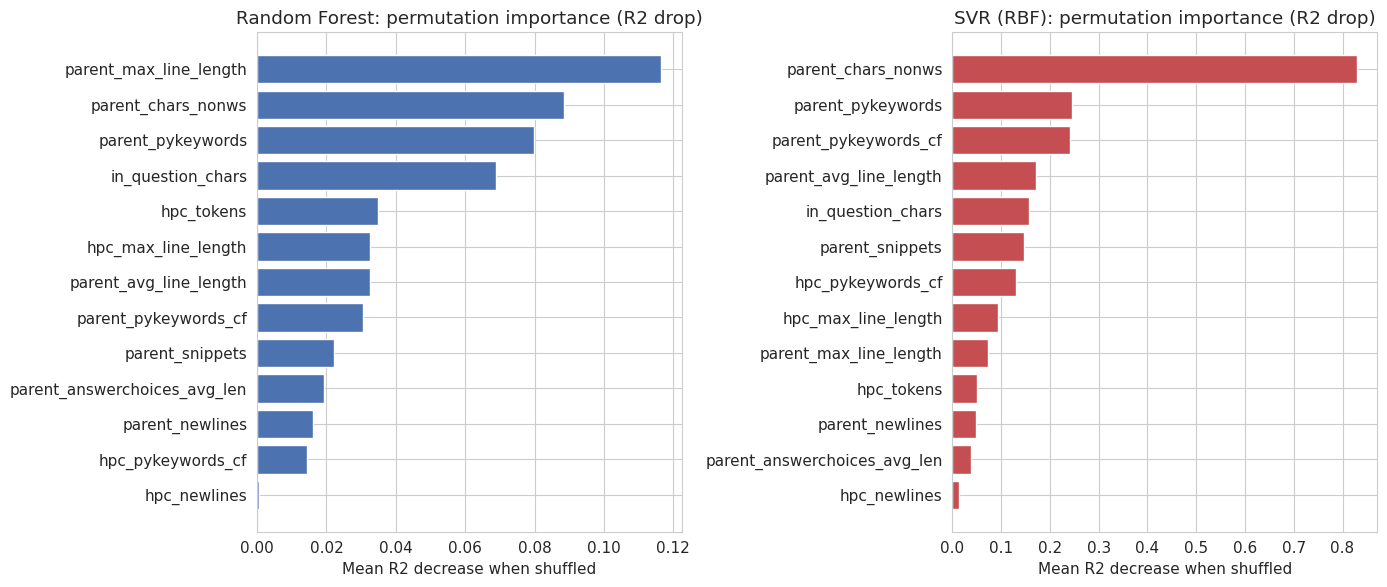

In [45]:
import matplotlib.pyplot as plt

imp_plot = importance.sort_values("rf_perm_r2drop")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(imp_plot["feature"], imp_plot["rf_perm_r2drop"], color="#4C72B0")
axes[0].set_title("Random Forest: permutation importance (R2 drop)")
axes[0].set_xlabel("Mean R2 decrease when shuffled")

svr_plot = importance.sort_values("svr_perm_r2drop")
axes[1].barh(svr_plot["feature"], svr_plot["svr_perm_r2drop"], color="#C44E52")
axes[1].set_title("SVR (RBF): permutation importance (R2 drop)")
axes[1].set_xlabel("Mean R2 decrease when shuffled")

plt.tight_layout()
plt.savefig("plot_ml_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

**Findings:**
- Both models rank the same parent-side surface features at the top: `parent_max_line_length`, `parent_chars_nonws`, and the keyword and length features. HPC features (what humans saw) stay secondary.
- This is the same conclusion reached three separate ways now: single-feature Spearman, OLS coefficients, and nonlinear ML importance all point to question-text length and surface complexity.
- SVR leans hard on `parent_chars_nonws`; RF spreads importance across the correlated length features. Expected, given the residual multicollinearity the VIF analysis flagged.

## Does feature importance change when controlling for model, method, subject?
First, add model/method/subject as one-hot dummies and see whether fit improves and whether the complexity-feature ranking shifts. The earlier OLS work moved from Adj R² = 0.223 to 0.253 with the same controls, so we're checking whether the nonlinear model behaves the same way.

In [46]:
dummies = pd.get_dummies(ml_data[["model", "method", "subject"]],
                         drop_first=True).astype(float).reset_index(drop=True)
X_ml_ext = pd.concat([X_ml, dummies], axis=1)

rf = RandomForestRegressor(n_estimators=400, random_state=RNG, n_jobs=-1)
r2_lean = cross_val_score(rf, X_ml,     y_ml, cv=kf, scoring="r2").mean()
r2_ext  = cross_val_score(rf, X_ml_ext, y_ml, cv=kf, scoring="r2").mean()
print(f"RF R2  lean features only:        {r2_lean:.4f}")
print(f"RF R2  + model/method/subject:    {r2_ext:.4f}")
print("(OLS moved 0.223 -> 0.253 with the same controls)\n")

rf.fit(X_ml_ext, y_ml)
imp_ext = pd.Series(rf.feature_importances_, index=X_ml_ext.columns).sort_values(ascending=False)
print("Top 10 RF importances WITH categorical controls:")
print(imp_ext.head(10).round(4).to_string())

RF R2  lean features only:        0.2903
RF R2  + model/method/subject:    0.3254
(OLS moved 0.223 -> 0.253 with the same controls)

Top 10 RF importances WITH categorical controls:
parent_max_line_length          0.1819
parent_chars_nonws              0.1331
parent_avg_line_length          0.1078
in_question_chars               0.0956
parent_pykeywords               0.0791
hpc_tokens                      0.0731
hpc_max_line_length             0.0604
parent_pykeywords_cf            0.0518
parent_answerchoices_avg_len    0.0414
parent_snippets                 0.0296


## Per-model random forest: does the top-feature ranking shift?
The controls above ask whether group identity matters on average. This asks something sharper: train a separate forest per model and compare the top features. If `parent_max_line_length` and `parent_chars_nonws` top the list for every model, the surface-complexity finding is robust across models. If models diverge, that's a real and reportable difference in how each one assigns difficulty.

In [47]:
MODEL_ORDER = ["gpt-4o-mini", "gpt-4o", "o1-mini", "o1", "o3-mini"]
per_model_imp = {}
for m in MODEL_ORDER:
    sub = ml_data[ml_data["model"] == m]
    Xm = sub[lean_features].astype(float)
    ym = sub["question_number"].astype(float).values
    rfm = RandomForestRegressor(n_estimators=400, random_state=RNG, n_jobs=-1).fit(Xm, ym)
    per_model_imp[m] = pd.Series(rfm.feature_importances_, index=lean_features)

per_model_imp_df = pd.DataFrame(per_model_imp)[MODEL_ORDER]
per_model_imp_df.to_csv("ml_per_model_importance.csv")

print("Per-model RF impurity importance (top 5 features each):\n")
for m in MODEL_ORDER:
    print(f"{m}:")
    print(per_model_imp_df[m].sort_values(ascending=False).head(5).round(4).to_string())
    print()

Per-model RF impurity importance (top 5 features each):

gpt-4o-mini:
parent_max_line_length    0.1925
parent_chars_nonws        0.1763
parent_avg_line_length    0.1392
in_question_chars         0.1209
parent_pykeywords         0.1050

gpt-4o:
parent_max_line_length    0.2443
parent_chars_nonws        0.1671
parent_avg_line_length    0.1037
in_question_chars         0.0976
parent_pykeywords         0.0909

o1-mini:
parent_max_line_length    0.2078
parent_chars_nonws        0.1702
parent_avg_line_length    0.1134
hpc_tokens                0.0889
in_question_chars         0.0794

o1:
parent_chars_nonws        0.1645
parent_max_line_length    0.1581
parent_avg_line_length    0.1486
in_question_chars         0.0923
hpc_max_line_length       0.0917

o3-mini:
parent_max_line_length    0.2149
parent_chars_nonws        0.1683
in_question_chars         0.1329
parent_avg_line_length    0.1074
parent_pykeywords         0.0736



### Interpretable ML

Random forest regression reaches R² = 0.2903, a few points above the OLS baseline of 0.223; SVR lands at R² = 0.2613. Adding model/method/subject controls lifts random forest to R² = 0.3245, the same direction the OLS extended model moved. The difficulty ceiling for this feature set sits around R² = 0.29 to 0.33.

Classification confirms a weak-but-real signal. Exact-level accuracy is 0.1907 (chance 0.10), within-one-level accuracy is 0.4489.

Feature importance converges with everything prior. Random forest and SVM both rank parent-side surface features (`parent_max_line_length`, `parent_chars_nonws`, keyword and length counts) at the top, the third independent method after Spearman and OLS to reach the same conclusion.

Importantly, the importance ranking is stable across models. Controlling for or splitting by model changes how much difficulty is explained, not which features drive it.

In summary, LLM-assigned difficulty tracks question-text length and surface complexity in a consistent, model-agnostic way, but a large fraction of the variance lives in dimensions these metrics do not capture.